In [149]:
import pandas as pd
import numpy as np
import yfinance as yf

# Day 1 - Data Stats

## 1.1. Data import

In [150]:
# TSM (Tech), JPM (Finanse), XOM (Energia), EEM (Rynki Wschodzące), SPY (Benchmark)
tickers = ['TSM', 'AAPL', 'JPM', 'XOM', 'EEM', 'SPY', 'GLD', 'BND']

start_date = '2019-01-01'
end_date = '2024-01-01'

# yfinance pobiera wiele metryk naraz. Od razu izolujemy 'Adj Close' na końcu wywołania.
# Używanie Adjusted Close jest krytyczne w modelach portfelowych, bo uwzględnia dywidendy i splity akcji.
data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=False)

[*********************100%***********************]  8 of 8 completed


In [151]:
data.head()

Price       Adj Close                                               \
Ticker           AAPL        BND        EEM         GLD        JPM   
Date                                                                 
2019-01-02  37.503716  64.321198  33.319088  121.330002  81.250214   
2019-01-03  33.768074  64.572388  32.714989  122.430000  80.095512   
2019-01-04  35.209610  64.377953  33.770039  121.440002  83.048248   
2019-01-07  35.131241  64.280678  33.846622  121.860001  83.105980   
2019-01-08  35.800957  64.199654  33.974247  121.529999  82.949272   

Price                                             Close             ...  \
Ticker             SPY        TSM        XOM       AAPL        BND  ...   
Date                                                                ...   
2019-01-02  224.995331  31.237255  50.001823  39.480000  79.370003  ...   
2019-01-03  219.626282  29.389696  49.234131  35.547501  79.680000  ...   
2019-01-04  226.982895  29.911461  51.049377  37.064999  79.440002  ...   
2019-01-07  228.772583  30.133846  51.314854  36.982498  79.320000  ...   
2019-01-08  230.921936  29.885794  51.687943  37.687500  79.220001  ...   

Price            Open                Volume                                \
Ticker            TSM        XOM       AAPL      BND        EEM       GLD   
Date                                                                        
2019-01-02  36.200001  67.349998  148158800  4142500   57198800  12776200   
2019-01-03  35.340000  70.000000  365248800  4908400   62767600  15440800   
2019-01-04  34.459999  69.639999  234428400  4583600  103055100  13334000   
2019-01-07  35.009998  71.250000  219111200  4121700   76597000   7473600   
2019-01-08  35.110001  72.540001  164101200  1745400   70518200   7643100   

Price                                                
Ticker           JPM        SPY       TSM       XOM  
Date                                                 
2019-01-02  15670900  126925200   5273100  16727200  
2019-01-03  16286400  144140700  15998000  13866100  
2019-01-04  16935200  142628800  14178200  16043600  
2019-01-07  15430700  103139100   6850800  10844200  
2019-01-08  13578800  102512600  11462600  11439000  

[5 rows x 48 columns]

In [152]:
data = data['Adj Close']

In [153]:
data.shape

(1258, 8)

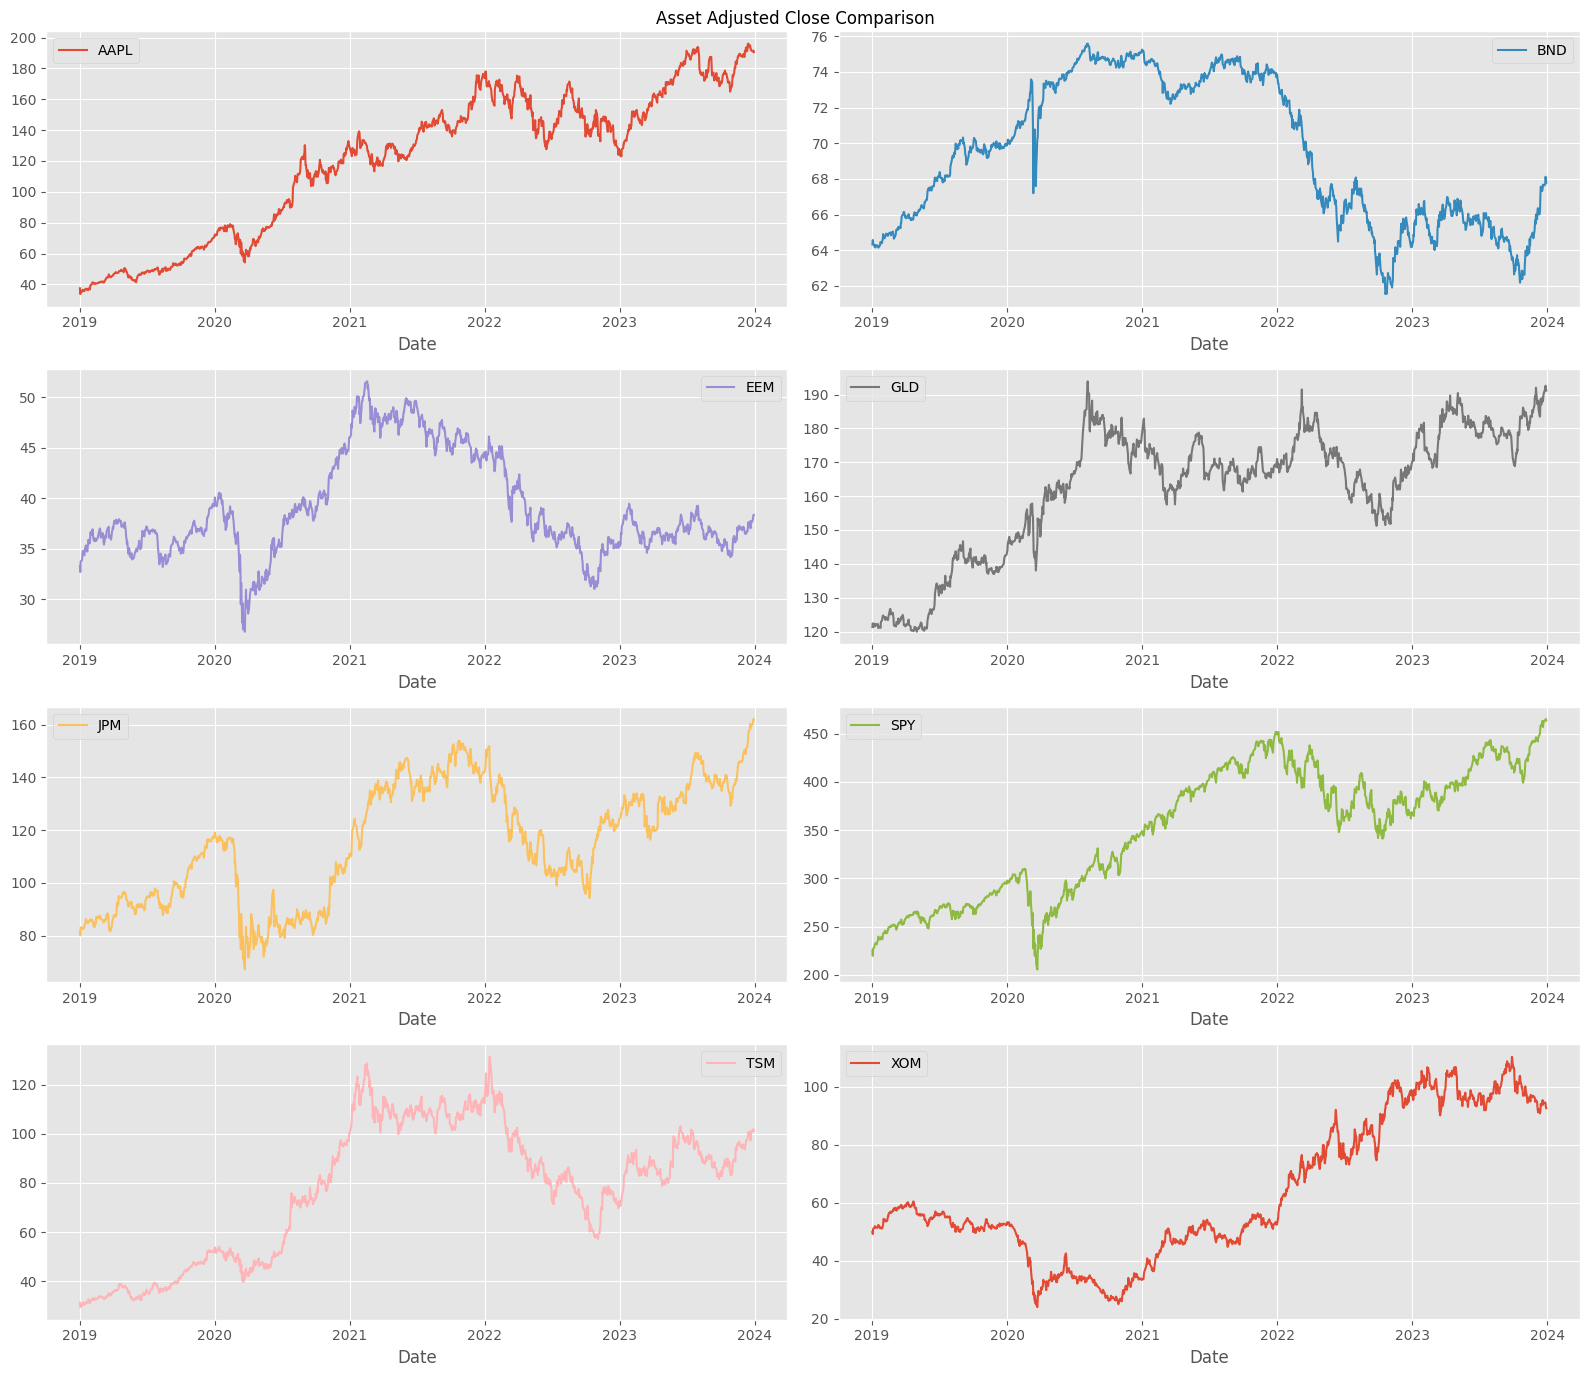

In [154]:
import matplotlib.pyplot as plt

plt.style.use('ggplot')

axes = data.plot(
    subplots=True, 
    layout=(4, 2),       
    figsize=(16, 14),  
    sharex=False,    
    grid=True,             
    linewidth=1.5,
    title="Asset Adjusted Close Comparison",
)
plt.tight_layout()      


## 1.2. Data Cleaning

In [155]:
print("Missing Data:", data.isnull().sum().sum())

Missing Data: 0


In [156]:
data.dropna()

Ticker,AAPL,BND,EEM,GLD,JPM,SPY,TSM,XOM
Date,,,,,,,,
2019-01-02,37.503716,64.321198,33.319088,121.330002,81.250214,224.995331,31.237255,50.001823
2019-01-03,33.768074,64.572388,32.714989,122.430000,80.095512,219.626282,29.389696,49.234131
2019-01-04,35.209610,64.377953,33.770039,121.440002,83.048248,226.982895,29.911461,51.049377
2019-01-07,35.131241,64.280678,33.846622,121.860001,83.105980,228.772583,30.133846,51.314854
2019-01-08,35.800957,64.199654,33.974247,121.529999,82.949272,230.921936,29.885794,51.687943
...,...,...,...,...,...,...,...,...
2023-12-22,191.609482,67.621117,37.554214,190.270004,159.387543,462.223297,100.357918,94.430161
2023-12-26,191.065140,67.685631,37.849838,191.720001,160.330200,464.175018,101.622719,94.643265
2023-12-27,191.164093,68.118889,38.069180,192.589996,161.291824,465.014343,101.817307,94.198502


## 1.3. Calculating Daily Log Returns

In [157]:
data.head()

Ticker,AAPL,BND,EEM,GLD,JPM,SPY,TSM,XOM
Date,,,,,,,,
2019-01-02,37.503716,64.321198,33.319088,121.330002,81.250214,224.995331,31.237255,50.001823
2019-01-03,33.768074,64.572388,32.714989,122.430000,80.095512,219.626282,29.389696,49.234131
2019-01-04,35.209610,64.377953,33.770039,121.440002,83.048248,226.982895,29.911461,51.049377
2019-01-07,35.131241,64.280678,33.846622,121.860001,83.105980,228.772583,30.133846,51.314854
2019-01-08,35.800957,64.199654,33.974247,121.529999,82.949272,230.921936,29.885794,51.687943


In [158]:
previous_prices = data.shift(1)
previous_prices


Ticker,AAPL,BND,EEM,GLD,JPM,SPY,TSM,XOM
Date,,,,,,,,
2019-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-03,37.503716,64.321198,33.319088,121.330002,81.250214,224.995331,31.237255,50.001823
2019-01-04,33.768074,64.572388,32.714989,122.430000,80.095512,219.626282,29.389696,49.234131
2019-01-07,35.209610,64.377953,33.770039,121.440002,83.048248,226.982895,29.911461,51.049377
2019-01-08,35.131241,64.280678,33.846622,121.860001,83.105980,228.772583,30.133846,51.314854
...,...,...,...,...,...,...,...,...
2023-12-22,192.678375,67.666298,37.735409,189.429993,159.482788,461.296295,99.774147,94.263367
2023-12-26,191.609482,67.621117,37.554214,190.270004,159.387543,462.223297,100.357918,94.430161
2023-12-27,191.065140,67.685631,37.849838,191.720001,160.330200,464.175018,101.622719,94.643265


In [159]:
log_returns = np.log(data/previous_prices)
log_returns = log_returns.dropna()  #drops first row
print(log_returns.shape)
log_returns.head()

(1257, 8)


Ticker,AAPL,BND,EEM,GLD,JPM,SPY,TSM,XOM
Date,,,,,,,,
2019-01-03,-0.104924,0.003898,-0.018297,0.009025,-0.014314,-0.024152,-0.060967,-0.015472
2019-01-04,0.041803,-0.003016,0.031741,-0.008119,0.036202,0.032947,0.017598,0.036206
2019-01-07,-0.002228,-0.001512,0.002265,0.003453,0.000695,0.007854,0.007407,0.005187
2019-01-08,0.018884,-0.001261,0.003764,-0.002712,-0.001887,0.009351,-0.008266,0.007244
2019-01-09,0.016839,0.001387,0.017625,0.006398,-0.001692,0.004663,0.018995,0.005261


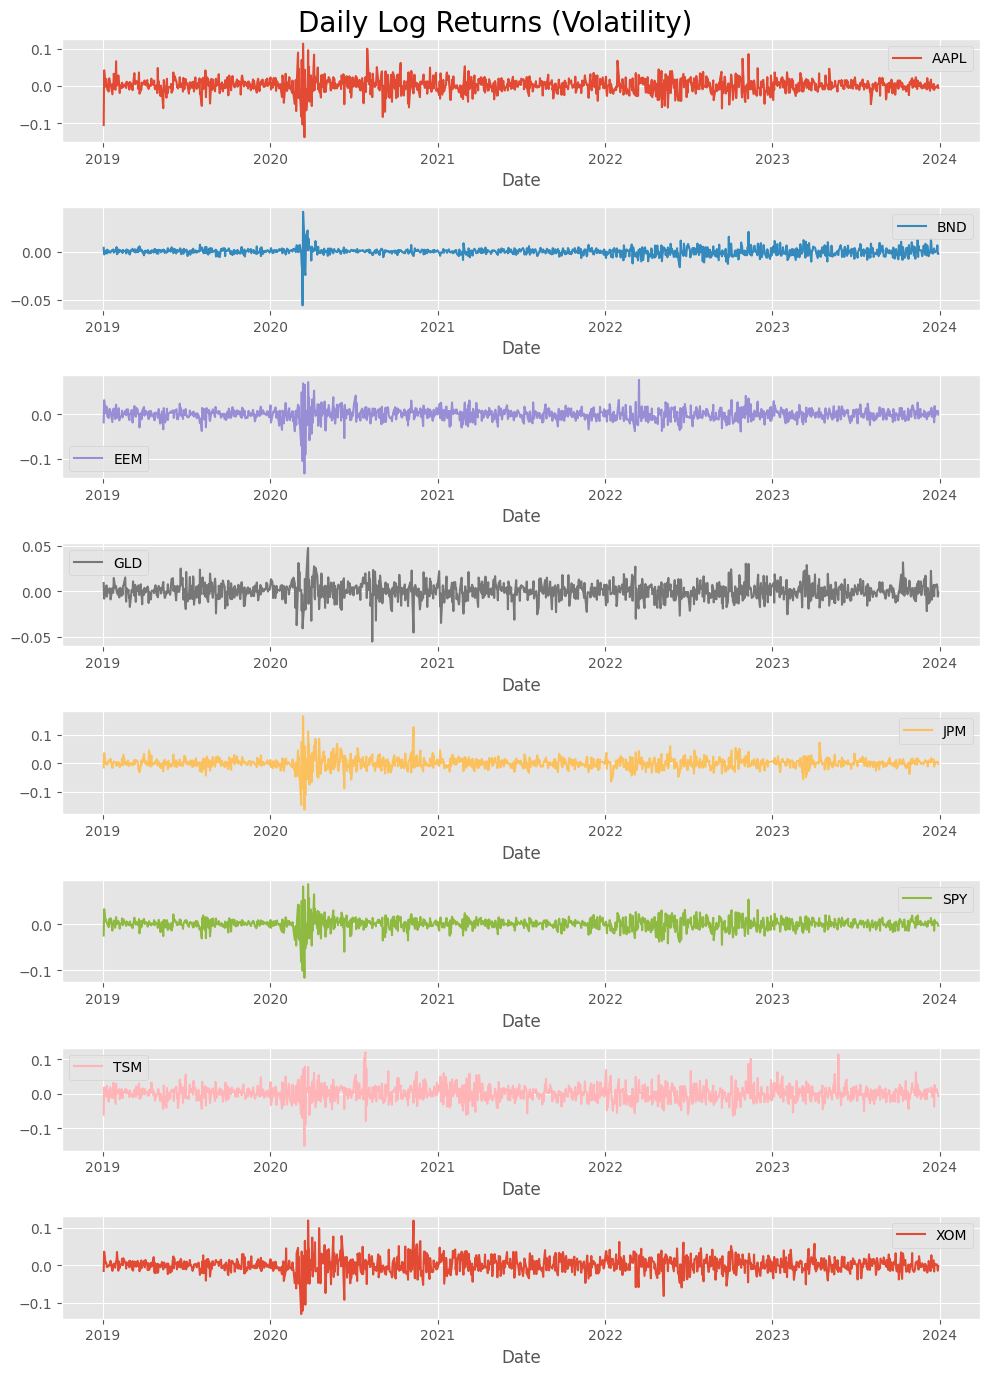

In [160]:
log_returns.plot(figsize=(10,14), subplots=True, sharex=False)
plt.suptitle('Daily Log Returns (Volatility)', fontsize=20)

plt.tight_layout()


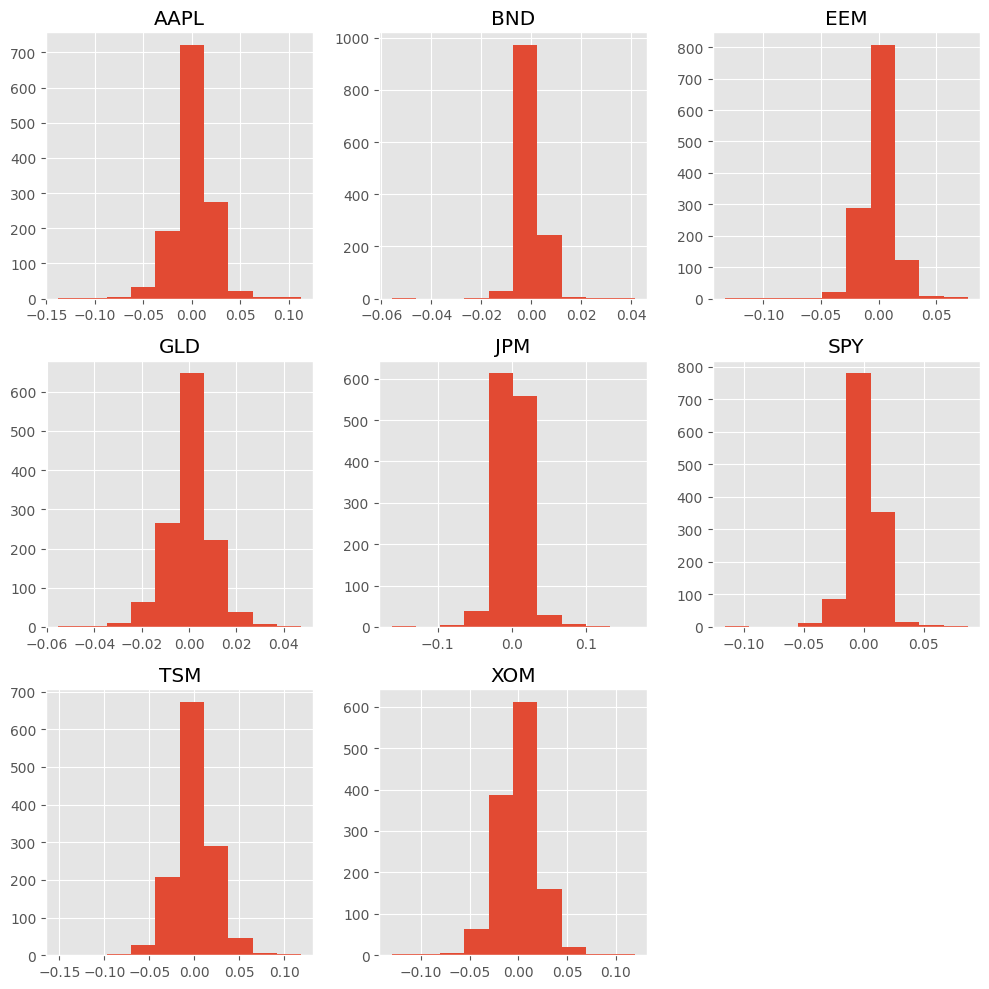

In [161]:
#returns histogram
log_returns.hist(figsize=(10,10))
plt.tight_layout()

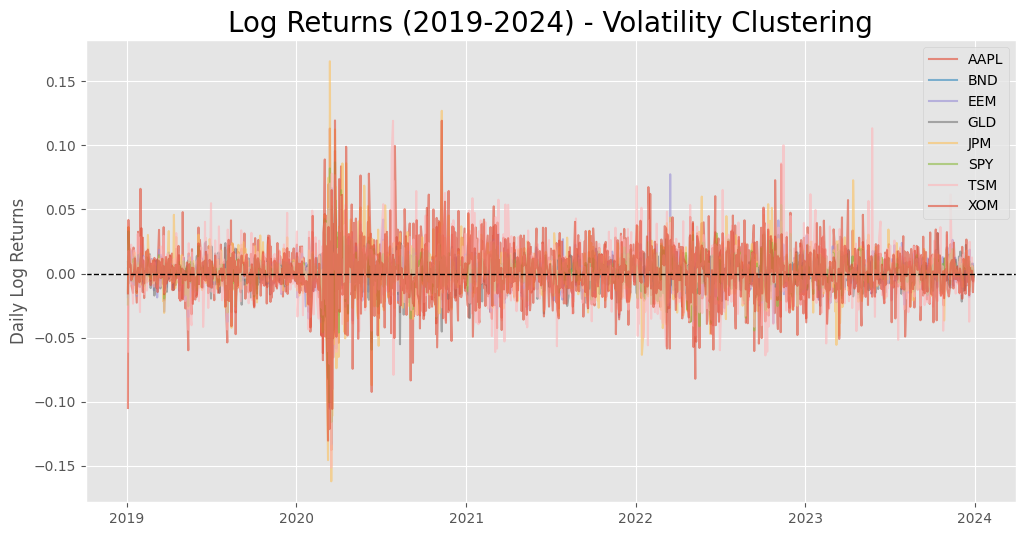

In [162]:
import matplotlib.pyplot as plt

# --- 1. Szereg czasowy (Wizualizacja Volatility Clustering) ---
# Powinieneś zauważyć, że w okresach kryzysów (np. marzec 2020) 
# wykres "szaleje" (duże odchylenia od zera) dla wszystkich aktywów naraz.
plt.figure(figsize=(12, 6))
plt.plot(log_returns, alpha=0.6)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Log Returns (2019-2024) - Volatility Clustering', fontsize=20)
plt.ylabel('Daily Log Returns')
plt.legend(log_returns.columns)
plt.show()


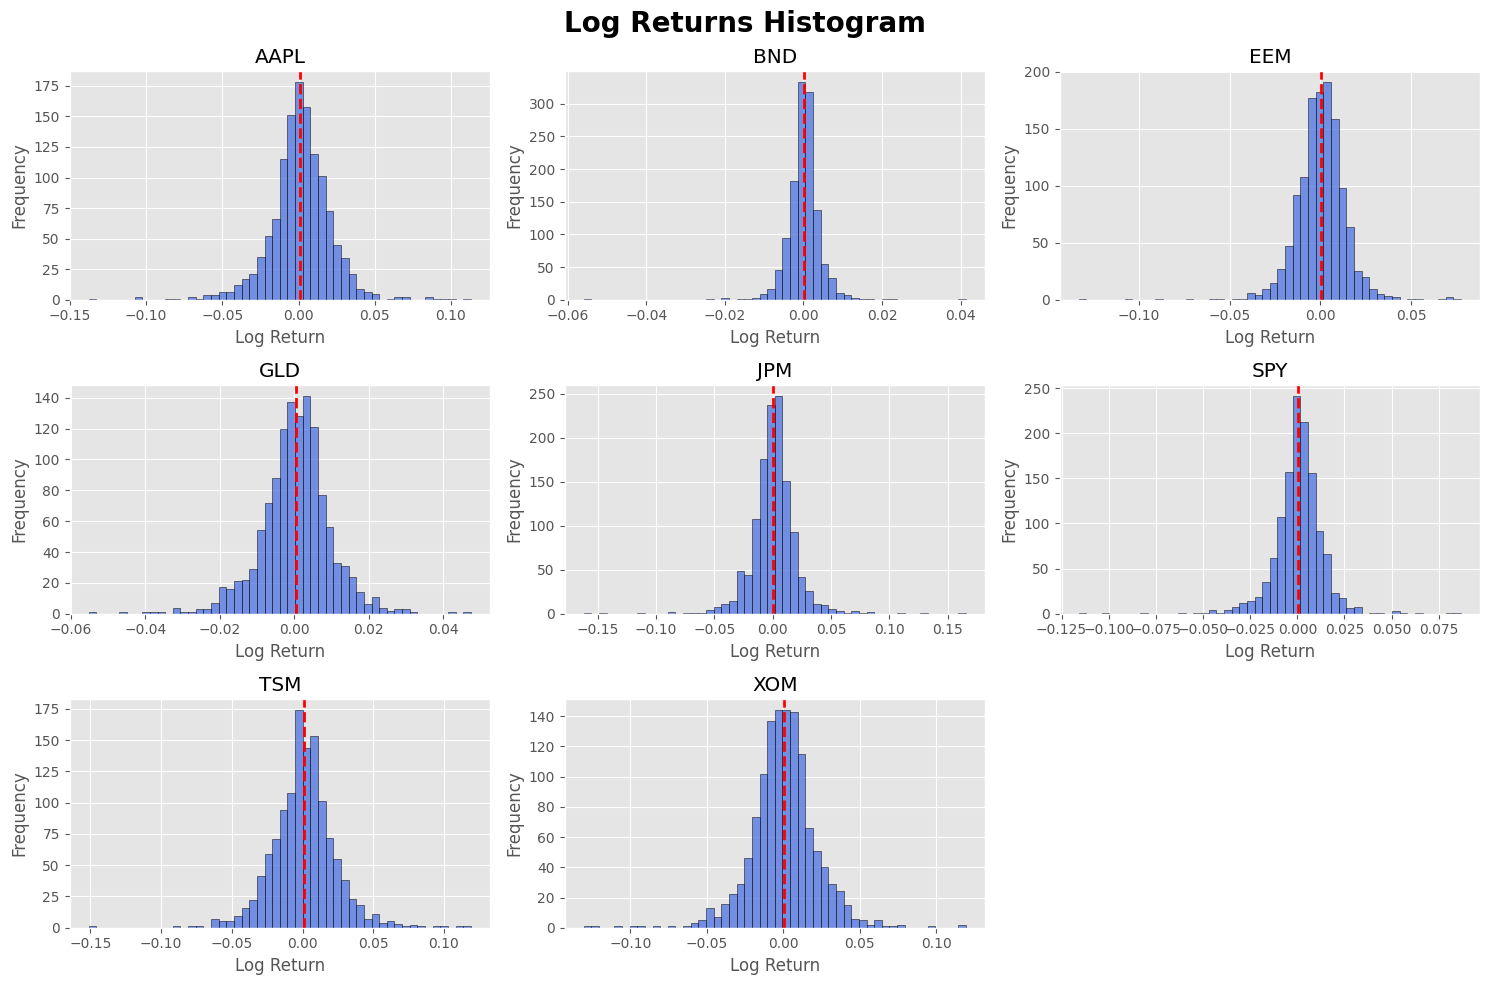

In [163]:
import matplotlib.pyplot as plt

# 1. Generate plots
axes = log_returns.hist(bins=50, figsize=(15, 10), color='royalblue', edgecolor='black', alpha=0.7)

# 2. Iterate through axes
for ax in axes.flatten():
    ticker = ax.get_title()
    
    # Check if the title corresponds to a valid column
    if ticker in log_returns.columns:
        mean_val = log_returns[ticker].mean()
        ax.axvline(mean_val, color='red', linestyle='dashed', linewidth=2)
        # Optional: Add a label for clarity
        ax.set_xlabel('Log Return')
        ax.set_ylabel('Frequency')
    else:
        # Hide empty subplots for a cleaner look
        ax.set_axis_off()

plt.suptitle('Log Returns Histogram', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

## 1.4. Covariance and the Covariance Martix

### Intuition - in normal covariance we are measuring deviations from a population average. in the financial context, we need to measure deviations from an average daily return (hence why we use the log returns dataframe as our data for the function)

In [164]:
daily_covar_martix = log_returns.cov()
daily_covar_martix

Ticker,AAPL,BND,EEM,GLD,JPM,SPY,TSM,XOM
Ticker,,,,,,,,
AAPL,0.000413,0.000012,0.000178,0.000016,0.000187,0.000217,0.000260,0.000142
BND,0.000012,0.000018,0.000010,0.000015,0.000003,0.000011,0.000010,-0.000003
EEM,0.000178,0.000010,0.000201,0.000025,0.000174,0.000147,0.000219,0.000150
GLD,0.000016,0.000015,0.000025,0.000089,-0.000010,0.000013,0.000025,0.000012
JPM,0.000187,0.000003,0.000174,-0.000010,0.000402,0.000196,0.000192,0.000257
SPY,0.000217,0.000011,0.000147,0.000013,0.000196,0.000176,0.000189,0.000160
TSM,0.000260,0.000010,0.000219,0.000025,0.000192,0.000189,0.000501,0.000152
XOM,0.000142,-0.000003,0.000150,0.000012,0.000257,0.000160,0.000152,0.000466


In [165]:
trading_days = 252

In [166]:
#the main diagonal of this is the annualized VARIANCE (covariance with itself)
annualized_covar_matrix = daily_covar_martix * 252
annualized_covar_matrix

Ticker,AAPL,BND,EEM,GLD,JPM,SPY,TSM,XOM
Ticker,,,,,,,,
AAPL,0.104004,0.003023,0.044897,0.004116,0.047067,0.054788,0.065439,0.035702
BND,0.003023,0.004583,0.002593,0.003841,0.000653,0.002653,0.002432,-0.000732
EEM,0.044897,0.002593,0.050666,0.006315,0.043811,0.036959,0.055228,0.037788
GLD,0.004116,0.003841,0.006315,0.022351,-0.002446,0.003392,0.006189,0.003077
JPM,0.047067,0.000653,0.043811,-0.002446,0.101372,0.049386,0.048264,0.064863
SPY,0.054788,0.002653,0.036959,0.003392,0.049386,0.044448,0.047560,0.040244
TSM,0.065439,0.002432,0.055228,0.006189,0.048264,0.047560,0.126200,0.038406
XOM,0.035702,-0.000732,0.037788,0.003077,0.064863,0.040244,0.038406,0.117536


In [167]:
# log annualized returns (average) 
log_annualized_returns_average_asset = log_returns.mean() * trading_days
log_annualized_returns_average_asset

Ticker
AAPL    0.325871
BND     0.010549
EEM     0.028170
GLD     0.091147
JPM     0.138290
SPY     0.145039
TSM     0.235629
XOM     0.123631
dtype: float64

In [168]:
#converted to actual annual returns (discrete)
# This creates a new Series of formatted strings
annualized_returns_average_asset = ((np.exp(log_annualized_returns_average_asset) - 1) * 100).map("{:.2f}%".format)
annualized_returns_average_asset


Ticker
AAPL    38.52%
BND      1.06%
EEM      2.86%
GLD      9.54%
JPM     14.83%
SPY     15.61%
TSM     26.57%
XOM     13.16%
dtype: str

In [169]:
#variances and volatilities
annual_variances = np.diag(annualized_covar_matrix)
print(annual_variances)

annual_volatilities = np.sqrt(annual_variances)
print(annual_volatilities)

volatility_series = pd.Series(annual_volatilities, index=annualized_covar_matrix.columns)

print()
print("--- ANNUALIZED VOLATILITY ---")
print(volatility_series)

[0.1040037  0.00458328 0.0506661  0.02235115 0.10137246 0.04444846
 0.12619989 0.11753567]
[0.32249605 0.0676999  0.22509132 0.14950301 0.31839042 0.21082804
 0.35524624 0.34283476]

--- ANNUALIZED VOLATILITY ---
Ticker
AAPL    0.322496
BND     0.067700
EEM     0.225091
GLD     0.149503
JPM     0.318390
SPY     0.210828
TSM     0.355246
XOM     0.342835
dtype: float64


## 1.5. Correlation (curiosity)

Text(0.5, 1.0, 'Correlation Matrix')

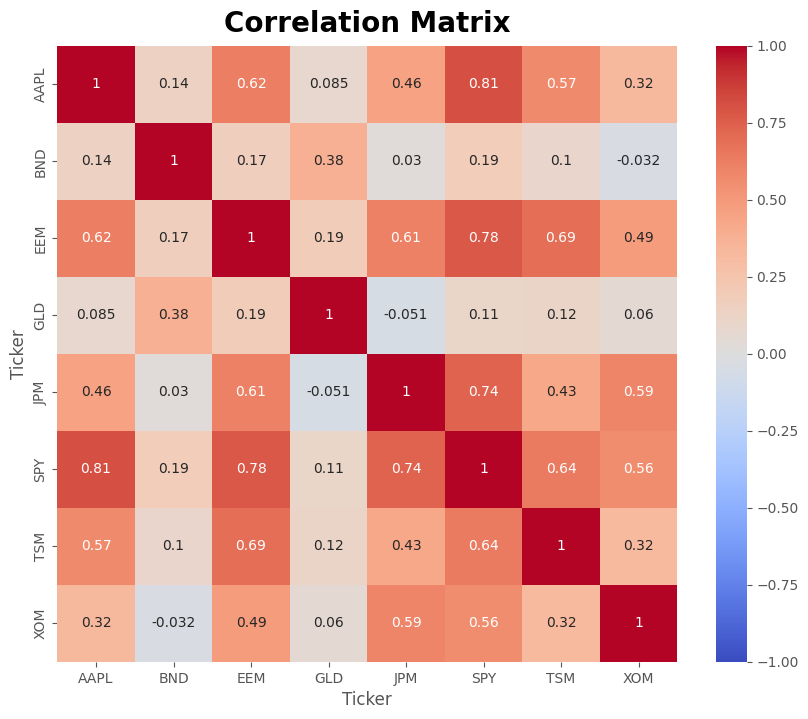

In [170]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(log_returns.corr(), annot=True, cmap='coolwarm',vmin=-1)
plt.title('Correlation Matrix', fontsize=20, pad=10, fontweight='demibold')

<Axes: xlabel='BND', ylabel='SPY'>

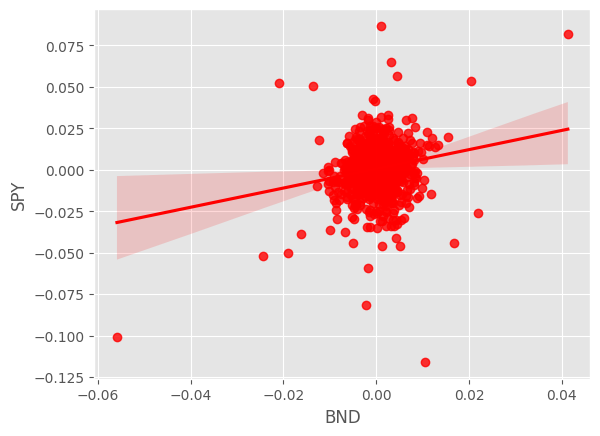

In [171]:
sns.regplot(x=log_returns['BND'], y=log_returns['SPY'], scatter=True, color='red')

# Day 2 - Equal-Weight Portfolio

## 2.1.1 Calculating Returns in 2 ways

In [172]:
#LOG VS SIMPLE TEST
initial_capital = 10000
equal_weights = np.array([1/data.columns.size] * data.columns.size)

### 2.1.1 SIMPLE:

In [173]:
simple_returns = data.pct_change().dropna()
simple_returns

Ticker,AAPL,BND,EEM,GLD,JPM,SPY,TSM,XOM
Date,,,,,,,,
2019-01-03,-0.099607,0.003905,-0.018131,0.009066,-0.014212,-0.023863,-0.059146,-0.015353
2019-01-04,0.042689,-0.003011,0.032250,-0.008086,0.036865,0.033496,0.017753,0.036870
2019-01-07,-0.002226,-0.001511,0.002268,0.003458,0.000695,0.007885,0.007435,0.005200
2019-01-08,0.019063,-0.001260,0.003771,-0.002708,-0.001886,0.009395,-0.008232,0.007271
2019-01-09,0.016982,0.001388,0.017781,0.006418,-0.001690,0.004673,0.019176,0.005275
...,...,...,...,...,...,...,...,...
2023-12-22,-0.005548,-0.000668,-0.004802,0.004434,-0.000597,0.002010,0.005851,0.001769
2023-12-26,-0.002841,0.000954,0.007872,0.007621,0.005914,0.004222,0.012603,0.002257
2023-12-27,0.000518,0.006401,0.005795,0.004538,0.005998,0.001808,0.001915,-0.004699


In [174]:
#mu (average) simple - looks useless, but probably used in Markotitz (the other average simple returns are different...) - CHECK THIS!
#
mu_simple = simple_returns.mean() * 252
print(mu_simple)
print()
print(annualized_returns_average_asset)

Ticker
AAPL    0.378031
BND     0.012835
EEM     0.053375
GLD     0.102324
JPM     0.189012
SPY     0.167224
TSM     0.298916
XOM     0.182362
dtype: float64

Ticker
AAPL    38.52%
BND      1.06%
EEM      2.86%
GLD      9.54%
JPM     14.83%
SPY     15.61%
TSM     26.57%
XOM     13.16%
dtype: str


In [175]:
#actual returns (simple)
portfolio_simple = np.dot(simple_returns, equal_weights)
print(portfolio_simple.shape)
print()
print(portfolio_simple)

(1257,)

[-0.02716756  0.02360324  0.00290056 ...  0.00278416 -0.00081884
 -0.00283065]


In [176]:
#final wealth simple:
wealth_simple = initial_capital * (1 + portfolio_simple).cumprod()
wealth_simple

array([ 9728.32443503,  9957.94443398,  9986.82809304, ...,
       21953.96033856, 21935.9836336 , 21873.89046112], shape=(1257,))

### 2.1.2. LOG METHOD

In [177]:
simple_returns

Ticker,AAPL,BND,EEM,GLD,JPM,SPY,TSM,XOM
Date,,,,,,,,
2019-01-03,-0.099607,0.003905,-0.018131,0.009066,-0.014212,-0.023863,-0.059146,-0.015353
2019-01-04,0.042689,-0.003011,0.032250,-0.008086,0.036865,0.033496,0.017753,0.036870
2019-01-07,-0.002226,-0.001511,0.002268,0.003458,0.000695,0.007885,0.007435,0.005200
2019-01-08,0.019063,-0.001260,0.003771,-0.002708,-0.001886,0.009395,-0.008232,0.007271
2019-01-09,0.016982,0.001388,0.017781,0.006418,-0.001690,0.004673,0.019176,0.005275
...,...,...,...,...,...,...,...,...
2023-12-22,-0.005548,-0.000668,-0.004802,0.004434,-0.000597,0.002010,0.005851,0.001769
2023-12-26,-0.002841,0.000954,0.007872,0.007621,0.005914,0.004222,0.012603,0.002257
2023-12-27,0.000518,0.006401,0.005795,0.004538,0.005998,0.001808,0.001915,-0.004699


In [178]:
daily_simple_returns = np.dot(simple_returns, equal_weights)
print(daily_simple_returns)
print()
print(daily_simple_returns.shape)

[-0.02716756  0.02360324  0.00290056 ...  0.00278416 -0.00081884
 -0.00283065]

(1257,)


In [179]:
#daily log return
daily_log_returns = np.log(1 + daily_simple_returns)
daily_log_returns


array([-0.02754342,  0.02332899,  0.00289637, ...,  0.00278029,
       -0.00081917, -0.00283467], shape=(1257,))

In [180]:
#total log return
total_log_return = daily_log_returns.sum()
total_log_return

np.float64(0.7827086161857812)

In [181]:
#total wealth
wealth_log = initial_capital * np.exp(total_log_return)
wealth_log

np.float64(21873.8904611181)

In [182]:
#for the wealth PATH use cumsum
wealth_log_path = initial_capital * np.exp(daily_log_returns.cumsum())
wealth_log_path

array([ 9728.32443503,  9957.94443398,  9986.82809304, ...,
       21953.96033856, 21935.9836336 , 21873.89046112], shape=(1257,))

In [183]:
#the wealth paths are mathematically identical, so this methodology works, but the log path is more elegant and numerically stable in practice.
print(wealth_simple)
print(wealth_log_path)

[ 9728.32443503  9957.94443398  9986.82809304 ... 21953.96033856
 21935.9836336  21873.89046112]
[ 9728.32443503  9957.94443398  9986.82809304 ... 21953.96033856
 21935.9836336  21873.89046112]


In [184]:
# czyli jak mam log returns to sposob przejscia w faktyczny return jest troche inny - bo mam zagwarantwana addytywnosc w czasie,
# ale nie mam zagwarantowanej addytywnosci miedzy poszczegolnymi aktywami,
# wiec zeby to obejsc biore returns miedzy aktywami z simple, i potem zmieniam recznie na log. inaczej nie przeskocze chyba.
# wiec simple returns lepiej tutaj chyba wykorzystac. nie zyskuje nic z logow.
# robienie log_returns = np.log(data/data.shift(1)) mija sie z celem bo calego portfela tutaj nie zlicze.

In [185]:
df = pd.Series(wealth_simple, index=(data.index[1:]))
print(df)
print()

Date
2019-01-03     9728.324435
2019-01-04     9957.944434
2019-01-07     9986.828093
2019-01-08    10018.553519
2019-01-09    10106.219457
                  ...     
2023-12-22    21787.874416
2023-12-26    21893.006813
2023-12-27    21953.960339
2023-12-28    21935.983634
2023-12-29    21873.890461
Length: 1257, dtype: float64



In [186]:
df.name = "Wealth"

# Join it to the DataFrame
data_combined = data.join(df)
data_combined

,AAPL,BND,EEM,GLD,JPM,SPY,TSM,XOM,Wealth
Date,,,,,,,,,
2019-01-02,37.503716,64.321198,33.319088,121.330002,81.250214,224.995331,31.237255,50.001823,NaN
2019-01-03,33.768074,64.572388,32.714989,122.430000,80.095512,219.626282,29.389696,49.234131,9728.324435
2019-01-04,35.209610,64.377953,33.770039,121.440002,83.048248,226.982895,29.911461,51.049377,9957.944434
2019-01-07,35.131241,64.280678,33.846622,121.860001,83.105980,228.772583,30.133846,51.314854,9986.828093
2019-01-08,35.800957,64.199654,33.974247,121.529999,82.949272,230.921936,29.885794,51.687943,10018.553519
...,...,...,...,...,...,...,...,...,...
2023-12-22,191.609482,67.621117,37.554214,190.270004,159.387543,462.223297,100.357918,94.430161,21787.874416
2023-12-26,191.065140,67.685631,37.849838,191.720001,160.330200,464.175018,101.622719,94.643265,21893.006813
2023-12-27,191.164093,68.118889,38.069180,192.589996,161.291824,465.014343,101.817307,94.198502,21953.960339


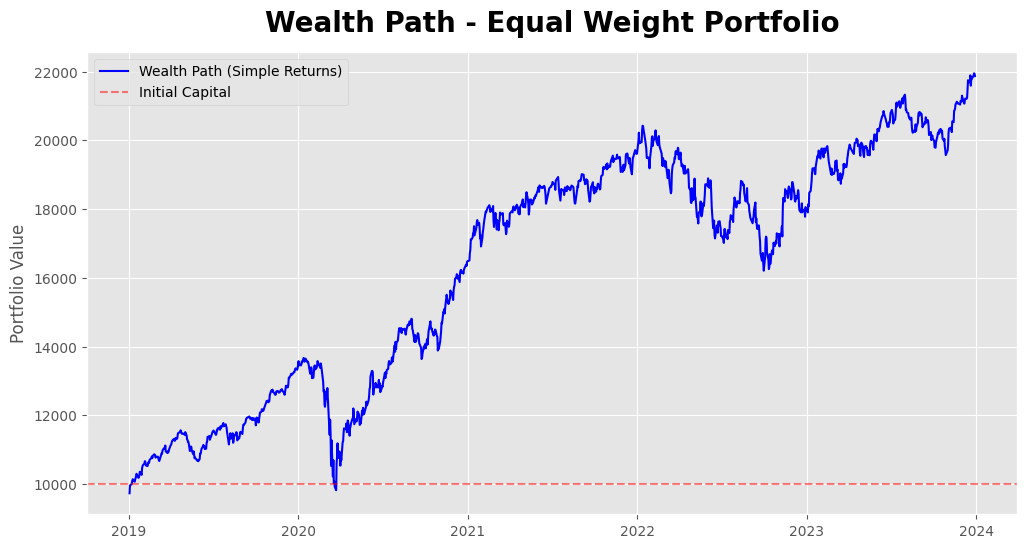

In [187]:
#vizing the wealth path.
plt.figure(figsize=(12, 6))
plt.plot(data_combined['Wealth'], label='Wealth Path (Simple Returns)', color='blue')
plt.axhline(y=initial_capital, color='red', linestyle='--', alpha=0.5, label='Initial Capital')
plt.title('Wealth Path - Equal Weight Portfolio', fontsize=20, pad=15, fontweight='bold')
plt.ylabel('Portfolio Value')
plt.legend()

In [188]:
#zle rozwiazanie
portfolio_log_wrong = np.dot(log_returns, equal_weights) # can't average logs across assets
portfolio_log_wrong


array([-0.02815049,  0.02317027,  0.00289003, ...,  0.00277416,
       -0.00084037, -0.00283669], shape=(1257,))

In [189]:
wealth_wrong = initial_capital * np.exp(portfolio_log_wrong.cumsum())
wealth_wrong

array([ 9722.42042105,  9950.32157243,  9979.11986558, ...,
       19907.18585953, 19890.46357324, 19834.12038004], shape=(1257,))

## 2.2. Equal-weight Portfolio Stats/Analysis - Reusable Function

In [190]:
# return rate: let's use the compound annual growth rate (CAGR) - it accounts for compounding (unlike annualized average simple return)
# It's a transformed yearly compounding formula.

### WRITING IT AGAIN TO THROW INTO A FUNCTION

In [191]:
equal_weights = np.ones(data.columns.size) / data.columns.size

In [192]:
eq_portfolio_returns = simple_returns @ equal_weights # equivalent to np.dot(simple_returns, equal_weights)
eq_portfolio_returns

Date
2019-01-03   -0.027168
2019-01-04    0.023603
2019-01-07    0.002901
2019-01-08    0.003177
2019-01-09    0.008750
                ...   
2023-12-22    0.000306
2023-12-26    0.004825
2023-12-27    0.002784
2023-12-28   -0.000819
2023-12-29   -0.002831
Length: 1257, dtype: float64

In [193]:
total_return_rate = (1 + eq_portfolio_returns).cumprod() - 1
total_return_rate

Date
2019-01-03   -0.027168
2019-01-04   -0.004206
2019-01-07   -0.001317
2019-01-08    0.001855
2019-01-09    0.010622
                ...   
2023-12-22    1.178787
2023-12-26    1.189301
2023-12-27    1.195396
2023-12-28    1.193598
2023-12-29    1.187389
Length: 1257, dtype: float64

In [194]:
# annualized average return rate - looks useless
annualized_average_return_rate = eq_portfolio_returns.mean() * trading_days
annualized_average_return_rate


np.float64(0.17300983276049034)

In [195]:
eq_portfolio_returns.mean()

np.float64(0.0006865469553987712)

In [196]:
eq_portfolio_returns

Date
2019-01-03   -0.027168
2019-01-04    0.023603
2019-01-07    0.002901
2019-01-08    0.003177
2019-01-09    0.008750
                ...   
2023-12-22    0.000306
2023-12-26    0.004825
2023-12-27    0.002784
2023-12-28   -0.000819
2023-12-29   -0.002831
Length: 1257, dtype: float64

In [197]:
# volatility

# daily variance
print("daily variance:",eq_portfolio_returns.var())

# annualized variance
print("annalized variance", eq_portfolio_returns.var() * trading_days)

# annualized volatility
annualized_volatility = np.sqrt(eq_portfolio_returns.var() * trading_days)
print("annualized volatility", annualized_volatility)

daily variance: 0.00012687358053752027
annalized variance 0.03197214229545511
annualized volatility 0.17880755659494682


In [198]:
# calc volatility/std function
def calculate_volatility (weights, data):
    portfolio_returns = data.pct_change() @ weights
    annualized_variance = portfolio_returns.var() * trading_days
    annualized_volatility = np.sqrt(annualized_variance)
    return annualized_volatility

In [199]:
equal_weights = np.ones(len(tickers)) * (1 / len(tickers))

calculate_volatility(equal_weights, data)

np.float64(0.17880755659494682)

In [200]:
# calc average return for sharpe
def calculate_mean_portfolio_returns (weights, data):
    portfolio_returns = data.pct_change() @ weights
    annualized_return = portfolio_returns.mean() * 252
    return annualized_return

In [201]:
data.pct_change() @ equal_weights

Date
2019-01-02         NaN
2019-01-03   -0.027168
2019-01-04    0.023603
2019-01-07    0.002901
2019-01-08    0.003177
                ...   
2023-12-22    0.000306
2023-12-26    0.004825
2023-12-27    0.002784
2023-12-28   -0.000819
2023-12-29   -0.002831
Length: 1258, dtype: float64

In [202]:
calculate_mean_portfolio_returns(equal_weights, data)

np.float64(0.17300983276049034)

In [203]:
#looks like for the function to compare portfolio's all i'd need is one that takes in weights and the price data, and the rest i can calculate based on that
# i should have a few functions. one for returns CAGR? one for wealth path? for plotting? and then the whole statistics thing like volatility and sharpe ratios...

In [204]:
trading_days

252

In [205]:
# i have the volatility. for sharpe ratio, i need the risk free rate and portfolio returns. 
# should i use cagr? no, arithmetic average is what is typically use in Sharpe, and is an input into Markowitza and CAPM (despite it not reporting true return due to drag)
eq_portfolio_returns.mean() * trading_days

np.float64(0.17300983276049034)

In [206]:
#cagr for fun (compound annual growth rate)
years = data.shape[0] / 252
print(years)
cagr = (wealth_simple[-1] / initial_capital) ** (1 / years) - 1
print(f"CAGR: {cagr:.2%}")

4.992063492063492
CAGR: 16.98%


In [207]:
wealth_simple

array([ 9728.32443503,  9957.94443398,  9986.82809304, ...,
       21953.96033856, 21935.9836336 , 21873.89046112], shape=(1257,))

In [208]:
#return at each time step
def calculate_return_path(weights, data):
    simple_port_ret = data.pct_change() @ weights
    log_port_ret = np.log(1 + simple_port_ret)
    return_path = np.exp(log_port_ret.cumsum())
    return return_path.to_numpy()

In [209]:
eq_return_path = calculate_return_path(equal_weights, data)
eq_return_path

array([       nan, 0.97283244, 0.99579444, ..., 2.19539603, 2.19359836,
       2.18738905], shape=(1258,))

In [210]:
#cagr function (for reporting true performance):
def calculate_cagr(weights, data):
    years = data.shape[0] / 252
    cagr = (calculate_return_path(weights, data)[-1]) ** (1 / years) - 1
    return cagr

In [211]:
calculate_cagr(equal_weights, data)

np.float64(0.16975063919459643)

In [212]:
#write function for importing the risk free rate for particular time periods.
def import_rfr(starting_date, ending_date):
    rfr = yf.download('^TNX', start=starting_date, end=ending_date)['Close'].mean().item() / 100
    return rfr


In [213]:
rfr = import_rfr(start_date, end_date)
rfr


[*********************100%***********************]  1 of 1 completed


0.022721041324881567

In [214]:
#sharpe ratio of my portfolio: (Rp - rfr) / volatility
eq_sharpe_ratio = (annualized_average_return_rate - rfr) / annualized_volatility
eq_sharpe_ratio

np.float64(0.8405058169664402)

In [215]:
#sharpe ratio function
def calculate_sharpe_ratio(weights, data):
    sharpe_ratio = (calculate_mean_portfolio_returns(weights, data) - rfr) / calculate_volatility(weights, data)
    return sharpe_ratio

In [216]:
calculate_sharpe_ratio(equal_weights, data)

np.float64(0.8405058169664402)

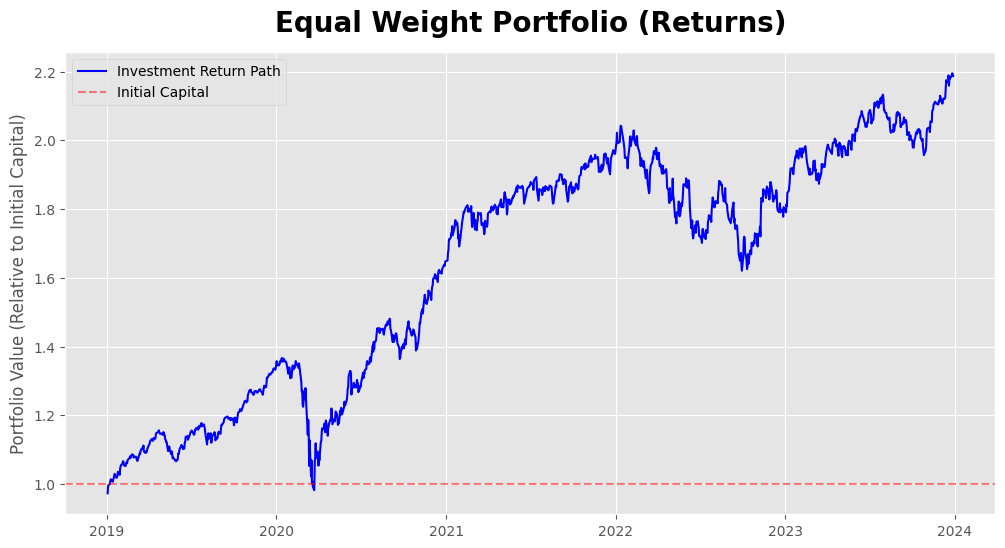

In [217]:
#viz return path (from function)
return_viz = calculate_return_path(equal_weights, data)

return_viz_series = pd.Series(return_viz, index=data.index)
return_viz_series

# viz
plt.figure(figsize=(12, 6))
plt.plot(return_viz_series, label='Investment Return Path', color='blue')
plt.axhline(y=1, color='red', linestyle='--', alpha=0.5, label='Initial Capital')
plt.title('Equal Weight Portfolio (Returns)', fontsize=20, pad=15, fontweight='bold')
plt.ylabel('Portfolio Value (Relative to Initial Capital)')
plt.legend()
plt.show()

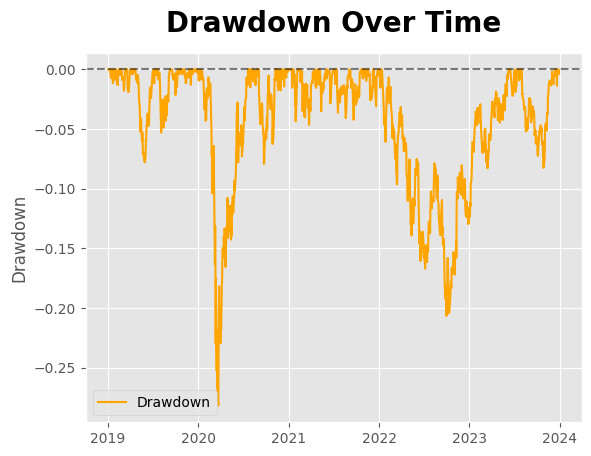

In [218]:
# computing drawdowns
return_viz_series.dropna()
drawdowns = (return_viz_series - return_viz_series.cummax()) / return_viz_series.cummax()
plt.plot(drawdowns, label='Drawdown', color='orange')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title('Drawdown Over Time', fontsize=20, pad=15, fontweight='bold')
plt.ylabel('Drawdown')
plt.legend()
plt.show()

In [219]:
max_drawdown = drawdowns.min()
max_drawdown

np.float64(-0.2816883130600156)

In [220]:
#CREATE A PLOTTING FUNCTION!

In [221]:
#plotting function for return path and drawdown
def plot_return_and_drawdown(weights, data):
    return_path = calculate_return_path(weights, data)
    return_viz_series = pd.Series(return_path, index=data.index)
    
    # Plot Return Path
    plt.figure(figsize=(12, 6))
    plt.plot(return_viz_series, label='Investment Return Path', color='blue')
    plt.axhline(y=1, color='red', linestyle='--', alpha=0.5, label='Initial Capital')
    plt.title('Equal Weight Portfolio (Returns)', fontsize=20, pad=15, fontweight='bold')
    plt.ylabel('Portfolio Value (Relative to Initial Capital)')
    plt.legend()
    plt.show()

    print(f'Total Return: {(return_path[-1] - 1):.2%}')
    
    # Compute and Plot Drawdowns
    drawdowns = (return_viz_series - return_viz_series.cummax()) / return_viz_series.cummax()
    plt.figure(figsize=(12, 6))
    plt.plot(drawdowns, label='Drawdown', color='orange')
    plt.axhline(0, color='black', linestyle='--', alpha=0.5)
    plt.title('Drawdown Over Time', fontsize=20, pad=15, fontweight='bold')
    plt.ylabel('Drawdown')
    plt.legend()
    plt.show()
    
    max_drawdown = drawdowns.min()
    print(f"Maximum Drawdown: {max_drawdown:.2%}")

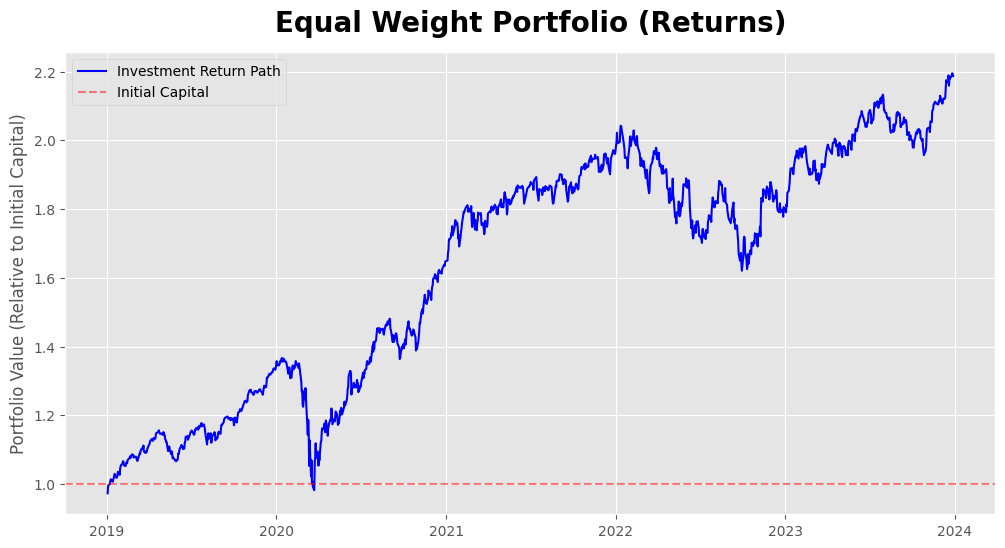

Total Return: 118.74%


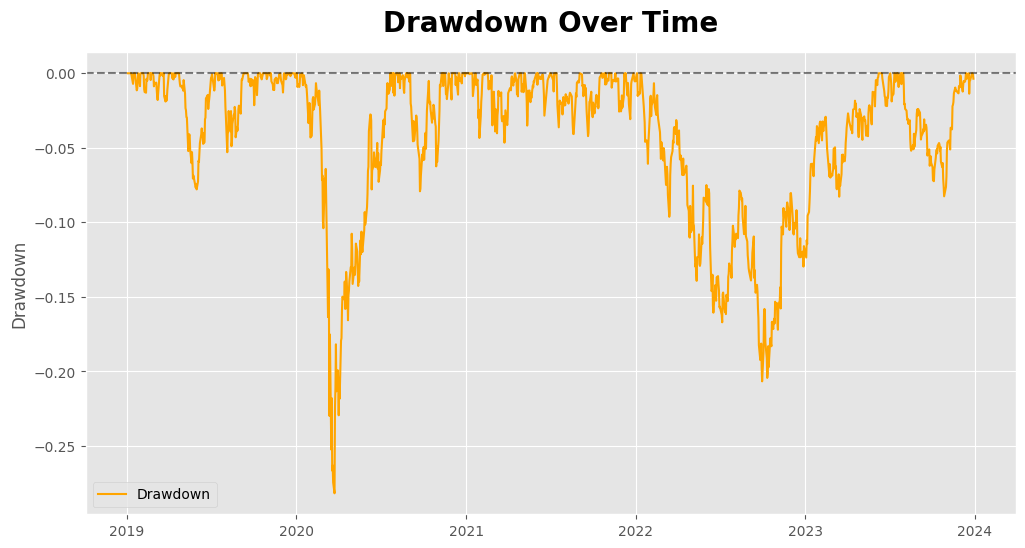

Maximum Drawdown: -28.17%


In [222]:
plot_return_and_drawdown(equal_weights, data)

# Day 3 - MPT Optimization

## 3.1. Inputs I Need

In [223]:
# let's start from scratch to understand this

# inputs: mu, covar matrix

# mu - expected returns based on historical returns for each asset
mu = data.pct_change().mean() * trading_days
mu


Ticker
AAPL    0.378031
BND     0.012835
EEM     0.053375
GLD     0.102324
JPM     0.189012
SPY     0.167224
TSM     0.298916
XOM     0.182362
dtype: float64

In [224]:
# sigma - annual covar matrix - this is used to compute risk
sigma = data.pct_change().cov() * trading_days
sigma.shape

(8, 8)

In [225]:
#functions needed:

#portfolio return (for each asset individually) based on mu (so an estimation, not accounting for compounding and non-additivity in time)
print(calculate_mean_portfolio_returns(equal_weights, data))

#portfolio volatility
print(calculate_volatility(equal_weights, data))

#sharpe ratio
calculate_sharpe_ratio(equal_weights, data)

#negative sharpe ratio
def calculate_negative_sharpe_ratio(weights, data):
    return -(calculate_sharpe_ratio(weights, data))



0.17300983276049034
0.17880755659494682


In [226]:
calculate_negative_sharpe_ratio(equal_weights, data)

np.float64(-0.8405058169664402)

## 3.2. Global Minimum Variance Portfolio (GMVP)

In [227]:
#defining bounds and constraints for scipy
constraints = ({
    'type':'eq',
    'fun':lambda weights: np.sum(weights) - 1
    })

n = len(mu)
bounds = [(0,1)] * n

In [228]:
#define an initial guess for our variable
init_guess = equal_weights
init_guess

array([0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125])

In [229]:
from scipy.optimize import minimize

In [230]:
minimum_variance_portfolio = minimize(calculate_volatility, init_guess, args=(data,), method='SLSQP', bounds=bounds, constraints=constraints)

In [231]:
minimum_variance_portfolio.x

array([0.00000000e+00, 9.19122806e-01, 0.00000000e+00, 3.21201876e-02,
       1.48452297e-02, 0.00000000e+00, 1.13866601e-18, 3.39117768e-02])

In [232]:
#the optimizer is saying that for the minimum global variance we should throw over 90% of the portfolio into bonds.
#what this serves as is a sort of benchmark - it's the leftmost point on the graph, and gives the minimum return we expect.

#let's check what the volatility is:
min_var_port_volatility = calculate_volatility(minimum_variance_portfolio.x, data)

#and what the retuns is (both average and CAGR):
min_var_port_mean_return = calculate_mean_portfolio_returns(minimum_variance_portfolio.x, data)
min_var_port_cagr = calculate_cagr(minimum_variance_portfolio.x, data)

#and the sharpe ratio:
min_var_port_sharpe = calculate_sharpe_ratio(minimum_variance_portfolio.x, data)

print('GMVP Volatility:', min_var_port_volatility)
print('GMVP Mean Returns:', min_var_port_mean_return)
print('GMVP CAGR', min_var_port_cagr)
print('GMVP Sharpe Ratio',min_var_port_sharpe)

GMVP Volatility: 0.06554124629752385
GMVP Mean Returns: 0.024073921591230937
GMVP CAGR 0.022142201105721737
GMVP Sharpe Ratio 0.02064166220166128


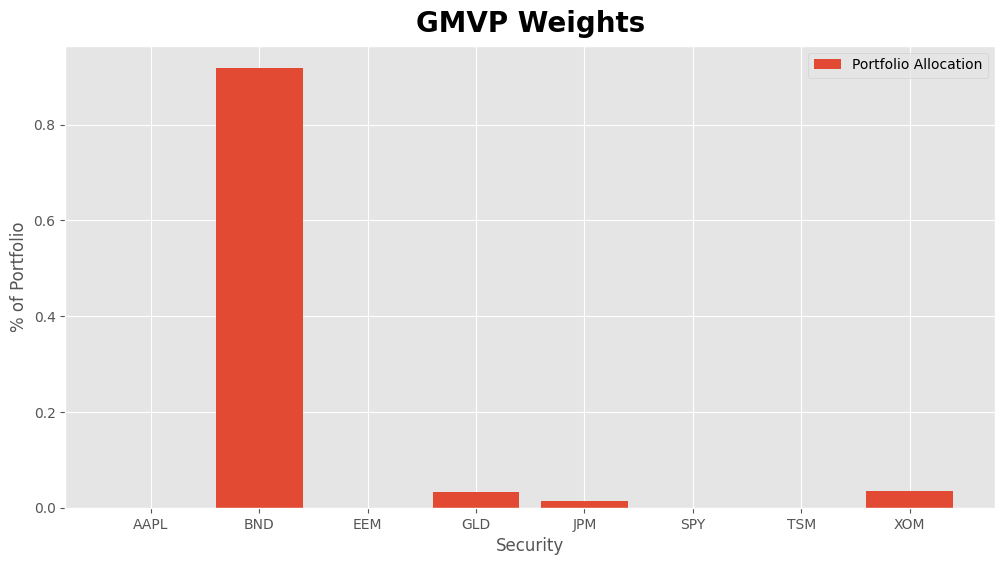

In [233]:
#plotting GMVP
plt.figure(figsize=(12,6))
plt.bar(data.columns, minimum_variance_portfolio.x, label='Portfolio Allocation')
plt.title('GMVP Weights', fontsize=20, pad=10, fontweight='semibold')
plt.xlabel('Security')
plt.ylabel('% of Portfolio')
plt.legend()

## 3.3. Tangency Portfolio (Max Sharpe Ratio)

In [234]:
#to maximize the sharpe we need to minimize the negative sharpe.

tangency_portfolio = minimize(calculate_negative_sharpe_ratio, init_guess, args=(data), constraints=constraints, bounds=bounds)
tangency_portfolio.x

array([4.49710602e-01, 0.00000000e+00, 1.86076181e-16, 4.39863128e-01,
       0.00000000e+00, 1.76995832e-17, 6.95111212e-02, 4.09151481e-02])

In [235]:
#calculating statistics

#let's check what the volatility is:
tangency_port_volatility = calculate_volatility(tangency_portfolio.x, data)

#and what the retuns is (both average and CAGR):
tangency_port_mean_return = calculate_mean_portfolio_returns(tangency_portfolio.x, data)
tangency_port_cagr = calculate_cagr(tangency_portfolio.x, data)

#and the sharpe ratio:
tangency_port_sharpe = calculate_sharpe_ratio(tangency_portfolio.x, data)

print('Tangency Portfolio Volatility:', tangency_port_volatility)
print('Tangency Portfolio Mean Returns:', tangency_port_mean_return)
print('Tangency Portfolio CAGR:', tangency_port_cagr)
print('Tangency Portfolio Sharpe Ratio:',tangency_port_sharpe)

Tangency Portfolio Volatility: 0.18390403652875717
Tangency Portfolio Mean Returns: 0.24325240958658895
Tangency Portfolio CAGR: 0.25365485385506403
Tangency Portfolio Sharpe Ratio: 1.1991654583787386


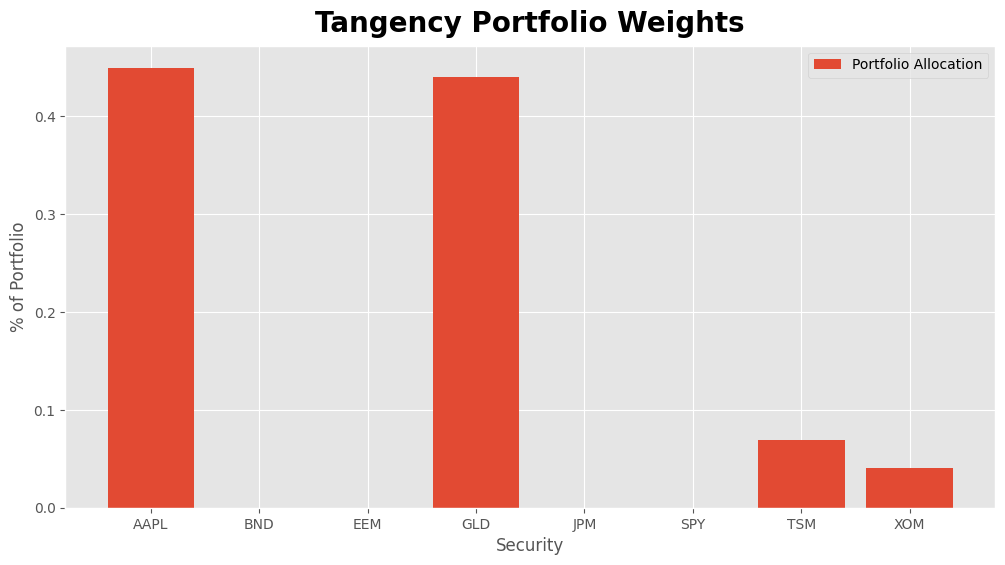

In [236]:
#plotting Tangency Portfolio
plt.figure(figsize=(12,6))
plt.bar(data.columns, tangency_portfolio.x, label='Portfolio Allocation')
plt.title('Tangency Portfolio Weights', fontsize=20, pad=10, fontweight='semibold')
plt.xlabel('Security')
plt.ylabel('% of Portfolio')
plt.legend()

In [237]:
calculate_return_path(equal_weights, data)

array([       nan, 0.97283244, 0.99579444, ..., 2.19539603, 2.19359836,
       2.18738905], shape=(1258,))

In [238]:
#creating a "calculate_max_drawdown" function:
def calculate_max_drawdown(weights, data):
    return_path = pd.Series(calculate_return_path(weights, data))
    cum_max = return_path.cummax()
    drawdowns = (cum_max - return_path) / cum_max
    max_drawdown = max(drawdowns[1:])
    return max_drawdown

calculate_max_drawdown(equal_weights, data)

0.2816883130600156

In [239]:
return_path = pd.Series(calculate_return_path(equal_weights, data))
cum_max = return_path.cummax()
drawdowns = (cum_max - return_path) / cum_max
max_drawdown = max(drawdowns[1:])


In [240]:
drawdowns

0            NaN
1       0.000000
2       0.000000
3       0.000000
4       0.000000
          ...   
1253    0.004793
1254    0.000000
1255    0.000000
1256    0.000819
1257    0.003647
Length: 1258, dtype: float64

In [241]:
return_path

0            NaN
1       0.972832
2       0.995794
3       0.998683
4       1.001855
          ...   
1253    2.178787
1254    2.189301
1255    2.195396
1256    2.193598
1257    2.187389
Length: 1258, dtype: float64

In [242]:
data

Ticker,AAPL,BND,EEM,GLD,JPM,SPY,TSM,XOM
Date,,,,,,,,
2019-01-02,37.503716,64.321198,33.319088,121.330002,81.250214,224.995331,31.237255,50.001823
2019-01-03,33.768074,64.572388,32.714989,122.430000,80.095512,219.626282,29.389696,49.234131
2019-01-04,35.209610,64.377953,33.770039,121.440002,83.048248,226.982895,29.911461,51.049377
2019-01-07,35.131241,64.280678,33.846622,121.860001,83.105980,228.772583,30.133846,51.314854
2019-01-08,35.800957,64.199654,33.974247,121.529999,82.949272,230.921936,29.885794,51.687943
...,...,...,...,...,...,...,...,...
2023-12-22,191.609482,67.621117,37.554214,190.270004,159.387543,462.223297,100.357918,94.430161
2023-12-26,191.065140,67.685631,37.849838,191.720001,160.330200,464.175018,101.622719,94.643265
2023-12-27,191.164093,68.118889,38.069180,192.589996,161.291824,465.014343,101.817307,94.198502


## 3.4. Maximum Returns For Given Volatility Levels

In [243]:
#maximizing returns for a given level of volatility - run it across a few: vol_targets = np.linspace(0.08, 0.25, 20)

#reassigning variables to have everything in one place:
n = len(data.columns)
bounds = [(0,1)] * n
init_guess = (np.ones(n)) / 8

#the list of vols we want to maximize returns for
vol_targets = np.linspace(0.08, 0.25, 20)

#maximing mean returns is minimizing negative mean returns
def calculate_neg_mean_portfolio_returns(weights, data):
    return -(calculate_mean_portfolio_returns(weights, data))

#creating arrays to store variables for nice reading (will later put into a dataframe):
opt_volatilities = vol_targets.copy()
opt_max_drawdown = np.zeros(len(vol_targets))
opt_mean_returns = np.zeros(len(vol_targets))
opt_cagr = np.zeros(len(vol_targets))
opt_sharpe_ratio = np.zeros(len(vol_targets))

#creating matrix to store weights (for later plotting):
opt_weights_matrix = np.zeros((len(vol_targets), n))

count = 0
#the optimization
for count, vol in enumerate(vol_targets):

    #set constraints
    constraints = [
        {'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1},
        {'type': 'eq', 'fun': lambda weights, v=vol: calculate_volatility(weights, data) - v}
    ]

    #optimize
    current_opt = minimize(calculate_neg_mean_portfolio_returns, init_guess, args=(data), constraints=constraints, bounds=bounds)
    current_opt_weights = current_opt.x

    #print(f'calculating optimal portfolio with {vol.round(4)} annualized volatility')

    #save portfolio stats
    opt_volatilities[count] = vol
    opt_max_drawdown[count] = calculate_max_drawdown(current_opt_weights, data)
    opt_mean_returns[count] = calculate_mean_portfolio_returns(current_opt_weights, data)
    opt_cagr[count] = calculate_cagr(current_opt_weights, data)
    opt_sharpe_ratio[count] = calculate_sharpe_ratio(current_opt_weights, data)

    #save weights:
    opt_weights_matrix[count] = current_opt_weights


#put portfolio stats into DataFrame
optimized_portfolios = pd.DataFrame({
    'Volatility': opt_volatilities,
    'Max Drawdown': opt_max_drawdown,
    'Mean Return': opt_mean_returns,
    'CAGR': opt_cagr,
    'Sharpe Ratio': opt_sharpe_ratio
})

#put weights into dataframe:
weights_df = pd.DataFrame(opt_weights_matrix, columns=data.columns)

print('')

print('done')
print('')

print('DataFrame with Results:')
print(optimized_portfolios)

print('DataFrame with weights')
print(weights_df)



done

DataFrame with Results:
    Volatility  Max Drawdown  Mean Return      CAGR  Sharpe Ratio
0     0.080000      0.138875     0.082036  0.081938      0.741442
1     0.088947      0.138542     0.100536  0.101286      0.874840
2     0.097895      0.139329     0.116865  0.118461      0.961683
3     0.106842      0.140617     0.131998  0.134457      1.022790
4     0.115789      0.144817     0.146374  0.149720      1.067914
5     0.124737      0.150355     0.160230  0.164488      1.102393
6     0.133684      0.158147     0.173711  0.178909      1.129448
7     0.142632      0.166668     0.186906  0.193073      1.151110
8     0.151579      0.174949     0.199881  0.207044      1.168759
9     0.160526      0.183020     0.212680  0.220867      1.183346
10    0.169474      0.189396     0.225068  0.234240      1.193973
11    0.178421      0.195143     0.236556  0.246537      1.198481
12    0.187368      0.200998     0.247363  0.258002      1.198933
13    0.196316      0.206554     0.257625  0.

In [244]:
init_guess

array([0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125])

In [245]:
optimized_portfolios

,Volatility,Max Drawdown,Mean Return,CAGR,Sharpe Ratio
0,0.080000,0.138875,0.082036,0.081938,0.741442
1,0.088947,0.138542,0.100536,0.101286,0.874840
2,0.097895,0.139329,0.116865,0.118461,0.961683
3,0.106842,0.140617,0.131998,0.134457,1.022790
4,0.115789,0.144817,0.146374,0.149720,1.067914
5,0.124737,0.150355,0.160230,0.164488,1.102393
6,0.133684,0.158147,0.173711,0.178909,1.129448
7,0.142632,0.166668,0.186906,0.193073,1.151110
8,0.151579,0.174949,0.199881,0.207044,1.168759
9,0.160526,0.183020,0.212680,0.220867,1.183346


In [246]:
weights_df

Ticker,AAPL,BND,EEM,GLD,JPM,SPY,TSM,XOM
0,0.103361,6.377725e-01,2.614495e-17,0.183204,2.115101e-02,0.000000e+00,0.017949,0.036562
1,0.137757,5.498025e-01,0.000000e+00,0.229927,2.240320e-02,0.000000e+00,0.022986,0.037123
2,0.168131,4.722060e-01,2.274534e-17,0.271087,2.350999e-02,0.000000e+00,0.027434,0.037632
3,0.196294,4.002435e-01,0.000000e+00,0.309320,2.458335e-02,9.375228e-18,0.031519,0.038041
4,0.222969,3.318541e-01,5.906597e-18,0.345682,2.551954e-02,5.592100e-17,0.035524,0.038452
5,0.249128,2.675847e-01,2.261928e-18,0.378567,2.636556e-02,2.864154e-18,0.039541,0.038813
6,0.273778,2.017712e-01,0.000000e+00,0.414883,2.762394e-02,7.666342e-17,0.042959,0.038984
7,0.298297,1.389672e-01,0.000000e+00,0.448178,2.851119e-02,3.832155e-17,0.046474,0.039573
8,0.322296,7.718206e-02,9.955179e-18,0.481129,2.862714e-02,0.000000e+00,0.050261,0.040506
9,0.346158,1.663712e-02,0.000000e+00,0.513151,2.956008e-02,0.000000e+00,0.053888,0.040606


In [247]:
#turning the code above into a function:

#NOTE: minimum volatility should be higher than 0.065, since that's the lowest we we're able to get with the GMV portfolio
def optimize_portfolios(data, vol_min, vol_max, n_points):
    n = len(data.columns)
    bounds = [(0,1)] * n
    init_guess = np.ones(n) * 8

    #the list of vols we want to maximize returns for
    vol_targets = np.linspace(vol_min, vol_max, n_points)

    #maximing mean returns is minimizing negative mean returns
    def calculate_neg_mean_portfolio_returns(weights, data):
        return -(calculate_mean_portfolio_returns(weights, data))

    #creating arrays to store variables for nice reading (will later put into a dataframe):
    opt_volatilities = vol_targets.copy()
    opt_max_drawdown = np.zeros(len(vol_targets))
    opt_mean_returns = np.zeros(len(vol_targets))
    opt_cagr = np.zeros(len(vol_targets))
    opt_sharpe_ratio = np.zeros(len(vol_targets))

    #creating matrix to store weights (for later plotting):
    opt_weights_matrix = np.zeros((len(opt_volatilities), n))

    #the optimization
    for count, vol in enumerate(vol_targets):

        #set constraints
        constraints = [
            {'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1},
            {'type': 'eq', 'fun': lambda weights, v=vol: calculate_volatility(weights, data) - v}
        ]

        #optimize
        current_opt = minimize(calculate_neg_mean_portfolio_returns, init_guess, args=(data), constraints=constraints, bounds=bounds)
        current_opt_weights = current_opt.x

        print(f'calculating optimal portfolio with {vol.round(4)} annualized volatility')

        #save data
        opt_volatilities[count] = vol
        opt_max_drawdown[count] = calculate_max_drawdown(current_opt_weights, data)
        opt_mean_returns[count] = calculate_mean_portfolio_returns(current_opt_weights, data)
        opt_cagr[count] = calculate_cagr(current_opt_weights, data)
        opt_sharpe_ratio[count] = calculate_sharpe_ratio(current_opt_weights, data)

        opt_weights_matrix[count] = current_opt_weights


    #put data into DataFrame
    optimized_portfolios = pd.DataFrame({
        'Volatility': opt_volatilities,
        'Max Drawdown': opt_max_drawdown,
        'Mean Return': opt_mean_returns,
        'CAGR': opt_cagr,
        'Sharpe Ratio': opt_sharpe_ratio
    })

    #put weights into dataframe:
    weights_df = pd.DataFrame(opt_weights_matrix, columns=data.columns)

    print('')
    print('done')

    return optimized_portfolios, weights_df
    

In [248]:
optimized_port_stats_df, optimized_weights_df = optimize_portfolios(data, 0.06, 0.25, 20)
optimized_port_stats_df

calculating optimal portfolio with 0.06 annualized volatility
calculating optimal portfolio with 0.07 annualized volatility
calculating optimal portfolio with 0.08 annualized volatility
calculating optimal portfolio with 0.09 annualized volatility
calculating optimal portfolio with 0.1 annualized volatility
calculating optimal portfolio with 0.11 annualized volatility
calculating optimal portfolio with 0.12 annualized volatility
calculating optimal portfolio with 0.13 annualized volatility
calculating optimal portfolio with 0.14 annualized volatility
calculating optimal portfolio with 0.15 annualized volatility
calculating optimal portfolio with 0.16 annualized volatility
calculating optimal portfolio with 0.17 annualized volatility
calculating optimal portfolio with 0.18 annualized volatility
calculating optimal portfolio with 0.19 annualized volatility
calculating optimal portfolio with 0.2 annualized volatility
calculating optimal portfolio with 0.21 annualized volatility
calculatin

,Volatility,Max Drawdown,Mean Return,CAGR,Sharpe Ratio
0,0.06,0.151604,0.024136,0.022206,0.021591
1,0.07,0.141039,0.054444,0.053312,0.453187
2,0.08,0.138877,0.082036,0.081938,0.741442
3,0.09,0.138512,0.102542,0.103391,0.886902
4,0.10,0.139653,0.120512,0.122310,0.977909
5,0.11,0.141139,0.137143,0.139912,1.040203
6,0.12,0.147520,0.152949,0.156721,1.085236
7,0.13,0.154637,0.168199,0.173007,1.119060
8,0.14,0.164186,0.183050,0.188930,1.145207
9,0.15,0.173506,0.197605,0.204591,1.165890


In [249]:
optimized_weights_df

Ticker,AAPL,BND,EEM,GLD,JPM,SPY,TSM,XOM
0,1.118837e-12,9.187756e-01,6.936691e-13,0.032068,1.472664e-02,2.761306e-13,3.779254e-13,0.034429
1,5.206004e-02,7.690098e-01,0.000000e+00,0.113481,1.926152e-02,0.000000e+00,1.045091e-02,0.035737
2,1.033590e-01,6.377686e-01,0.000000e+00,0.183210,2.115211e-02,1.720198e-17,1.795073e-02,0.036560
3,1.414905e-01,5.402325e-01,0.000000e+00,0.235046,2.251465e-02,0.000000e+00,2.352290e-02,0.037194
4,1.749106e-01,4.548853e-01,3.620766e-17,0.280287,2.374830e-02,0.000000e+00,2.845454e-02,0.037715
5,2.058159e-01,3.756860e-01,2.621744e-17,0.322450,2.488310e-02,9.605486e-17,3.295676e-02,0.038208
6,2.348405e-01,3.002007e-01,1.810515e-17,0.362600,2.618850e-02,7.703708e-17,3.754641e-02,0.038624
7,2.634463e-01,2.279246e-01,0.000000e+00,0.400974,2.715360e-02,3.177725e-17,4.153110e-02,0.038971
8,2.911503e-01,1.573197e-01,4.178267e-17,0.438441,2.830452e-02,0.000000e+00,4.540971e-02,0.039375
9,3.180735e-01,8.790558e-02,0.000000e+00,0.475488,2.862897e-02,1.323726e-17,4.954750e-02,0.040356


## 3.5. Plotting Efficient Frontier

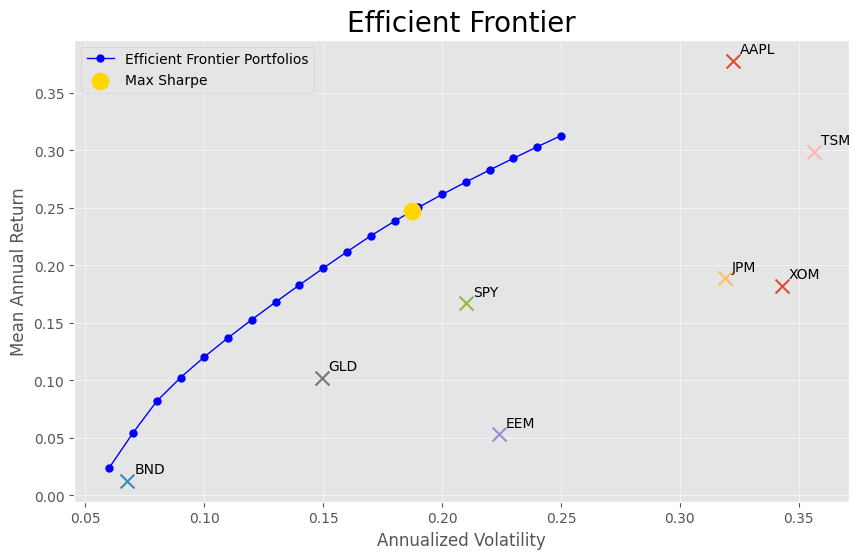

In [250]:
#plotting the efficient frontier:


plt.figure(figsize=(10, 6))
plt.plot(optimized_port_stats_df['Volatility'], optimized_port_stats_df['Mean Return'], 
         'b-o', linewidth=1, markersize=5, label='Efficient Frontier Portfolios')
plt.xlabel('Annualized Volatility')
plt.ylabel('Mean Annual Return')
plt.title('Efficient Frontier', fontsize=20)
plt.grid(True, alpha=0.5)
plt.legend()

#adding our individual assets and portfolios computed earlier to the plot:

#plot of our assets.
for col in data.columns:
    single_weight = np.zeros(n)
    single_weight[list(data.columns).index(col)] = 1.0
    single_weight
    asset_vol = calculate_volatility(single_weight, data)
    asset_ret = calculate_mean_portfolio_returns(single_weight, data)
    plt.scatter(asset_vol, asset_ret, marker='x', s=100, zorder=5)
    plt.annotate(col, (asset_vol, asset_ret), textcoords="offset points", xytext=(5,5))

#max sharpe portfolio (from the simulated ones - not the global one)
max_sharpe_idx = optimized_portfolios['Sharpe Ratio'].idxmax()
best = optimized_portfolios.loc[max_sharpe_idx]
plt.scatter(best['Volatility'], best['Mean Return'], 
            color='gold', s=150, zorder=6, label='Max Sharpe')
plt.legend()


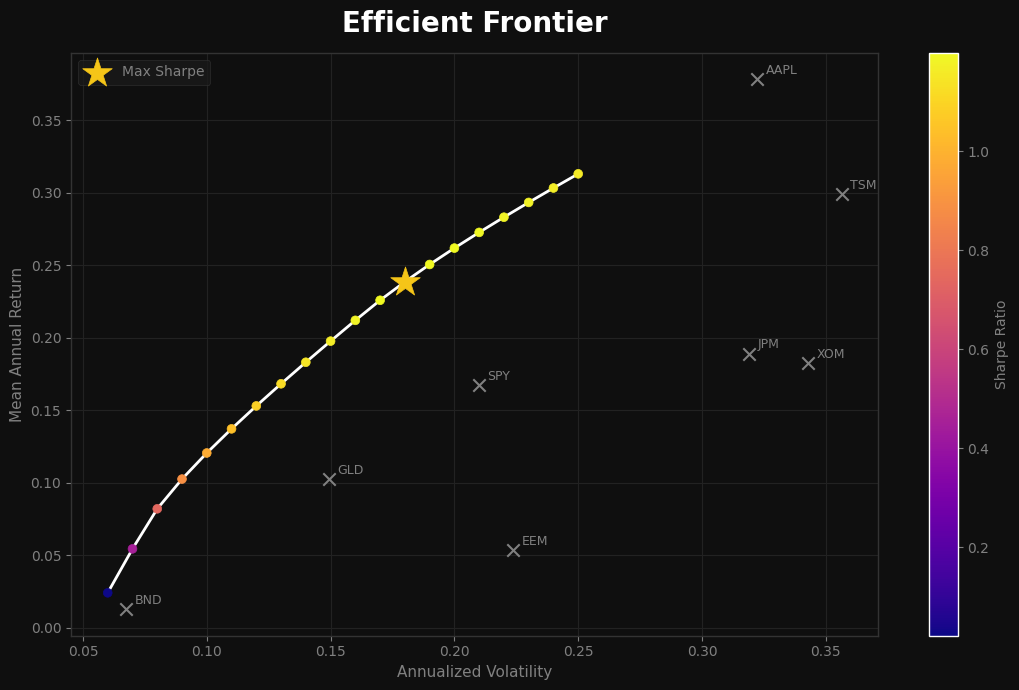

In [251]:
# plotting the efficient frontier
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#0f0f0f')

# frontier line
ax.plot(optimized_port_stats_df['Volatility'], optimized_port_stats_df['Mean Return'],
        color='white', linewidth=2, zorder=2)

# frontier points colored by sharpe ratio
sc = ax.scatter(optimized_port_stats_df['Volatility'], optimized_port_stats_df['Mean Return'],
                c=optimized_port_stats_df['Sharpe Ratio'], cmap='plasma',
                s=40, zorder=3)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Sharpe Ratio', color='grey', fontsize=10)
cbar.ax.yaxis.set_tick_params(color='grey')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='grey')

# individual assets
for col in data.columns:
    single_weight = np.zeros(n)
    single_weight[list(data.columns).index(col)] = 1.0
    asset_vol = calculate_volatility(single_weight, data)
    asset_ret = calculate_mean_portfolio_returns(single_weight, data)
    ax.scatter(asset_vol, asset_ret, marker='x', s=80, color='grey', zorder=4, linewidths=1.5)
    ax.annotate(col, (asset_vol, asset_ret), textcoords="offset points",
                xytext=(6, 4), color='grey', fontsize=9)

# max sharpe portfolio
max_sharpe_idx = optimized_port_stats_df['Sharpe Ratio'].idxmax()
best = optimized_port_stats_df.loc[max_sharpe_idx]
ax.scatter(best['Volatility'], best['Mean Return'],
           color='#f5c518', s=500, zorder=5, marker='*', label='Max Sharpe')

# formatting
ax.set_xlabel('Annualized Volatility', color='grey', fontsize=11)
ax.set_ylabel('Mean Annual Return', color='grey', fontsize=11)
ax.set_title('Efficient Frontier', color='white', fontsize=20, fontweight='bold', pad=15)
ax.tick_params(colors='grey')
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')
ax.grid(True, color='#222222', linewidth=0.8)
ax.legend(facecolor='#1a1a1a', edgecolor='#333333', labelcolor='grey', fontsize=10)

plt.tight_layout()
plt.show()

In [252]:
optimized_weights_df

Ticker,AAPL,BND,EEM,GLD,JPM,SPY,TSM,XOM
0,1.118837e-12,9.187756e-01,6.936691e-13,0.032068,1.472664e-02,2.761306e-13,3.779254e-13,0.034429
1,5.206004e-02,7.690098e-01,0.000000e+00,0.113481,1.926152e-02,0.000000e+00,1.045091e-02,0.035737
2,1.033590e-01,6.377686e-01,0.000000e+00,0.183210,2.115211e-02,1.720198e-17,1.795073e-02,0.036560
3,1.414905e-01,5.402325e-01,0.000000e+00,0.235046,2.251465e-02,0.000000e+00,2.352290e-02,0.037194
4,1.749106e-01,4.548853e-01,3.620766e-17,0.280287,2.374830e-02,0.000000e+00,2.845454e-02,0.037715
5,2.058159e-01,3.756860e-01,2.621744e-17,0.322450,2.488310e-02,9.605486e-17,3.295676e-02,0.038208
6,2.348405e-01,3.002007e-01,1.810515e-17,0.362600,2.618850e-02,7.703708e-17,3.754641e-02,0.038624
7,2.634463e-01,2.279246e-01,0.000000e+00,0.400974,2.715360e-02,3.177725e-17,4.153110e-02,0.038971
8,2.911503e-01,1.573197e-01,4.178267e-17,0.438441,2.830452e-02,0.000000e+00,4.540971e-02,0.039375
9,3.180735e-01,8.790558e-02,0.000000e+00,0.475488,2.862897e-02,1.323726e-17,4.954750e-02,0.040356


## 3.6. Plotting Optimal Weights For Each Portfolio

/var/folders/4v/1cr4vn8x4yv_p93m1plqw2s80000gn/T/ipykernel_23290/671548331.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x, rotation=45, ha='right')


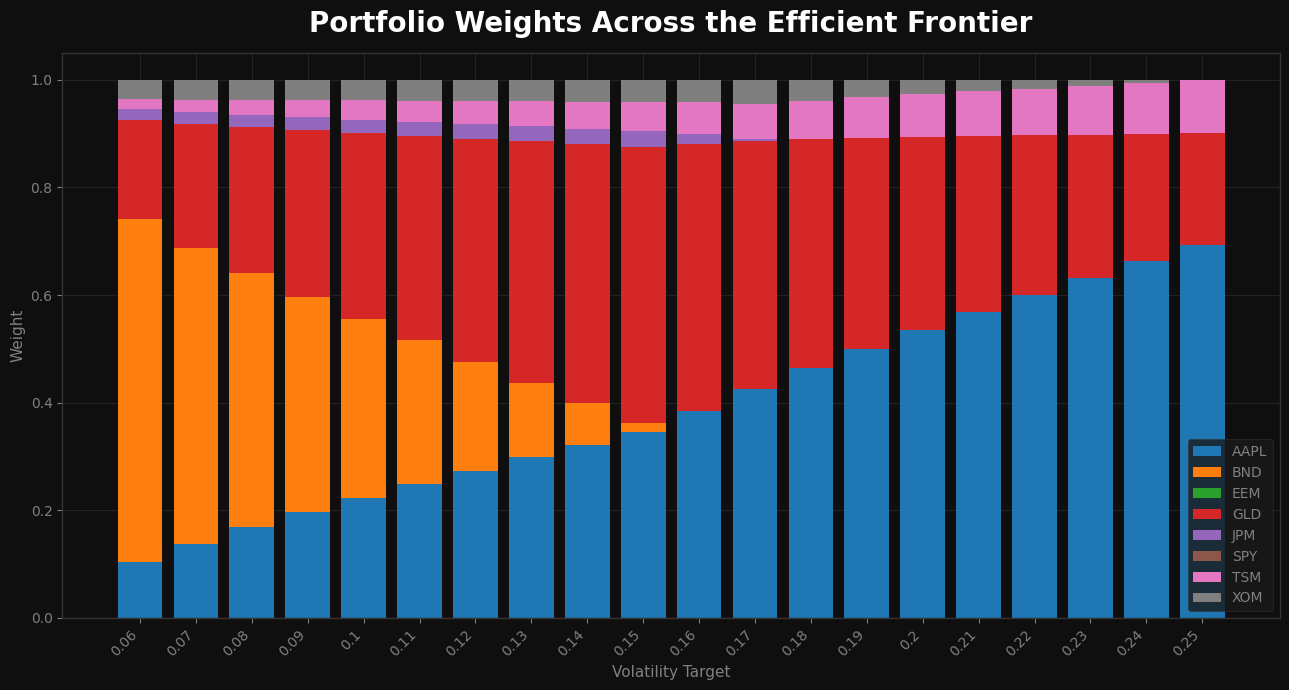

In [253]:
fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#0f0f0f')

weights_only = weights_df.drop(columns='Volatility') if 'Volatility' in weights_df.columns else weights_df
x = optimized_port_stats_df['Volatility'].round(3).astype(str)
bottom = np.zeros(len(weights_df))

#colors = plt.cm.plasma(np.linspace(0.1, 0.9, n))
colors = plt.cm.tab10.colors

for i, col in enumerate(weights_only.columns):
    ax.bar(x, weights_only[col], bottom=bottom, label=col, color=colors[i])
    bottom += weights_only[col].values

ax.set_xlabel('Volatility Target', color='grey', fontsize=11)
ax.set_ylabel('Weight', color='grey', fontsize=11)
ax.set_title('Portfolio Weights Across the Efficient Frontier', color='white', fontsize=20, fontweight='bold', pad=15)
ax.tick_params(colors='grey')
ax.set_xticklabels(x, rotation=45, ha='right')
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')
ax.grid(True, color='#222222', linewidth=0.8)
ax.legend(facecolor='#1a1a1a', edgecolor='#333333', labelcolor='grey', fontsize=10)

plt.tight_layout()
plt.show()

### digression...

In [254]:
#checking gold performance because the optimizer seems to like it - not great - the lack of correlation to other assets must be the reason.

annualized_covar_matrix

Ticker,AAPL,BND,EEM,GLD,JPM,SPY,TSM,XOM
Ticker,,,,,,,,
AAPL,0.104004,0.003023,0.044897,0.004116,0.047067,0.054788,0.065439,0.035702
BND,0.003023,0.004583,0.002593,0.003841,0.000653,0.002653,0.002432,-0.000732
EEM,0.044897,0.002593,0.050666,0.006315,0.043811,0.036959,0.055228,0.037788
GLD,0.004116,0.003841,0.006315,0.022351,-0.002446,0.003392,0.006189,0.003077
JPM,0.047067,0.000653,0.043811,-0.002446,0.101372,0.049386,0.048264,0.064863
SPY,0.054788,0.002653,0.036959,0.003392,0.049386,0.044448,0.047560,0.040244
TSM,0.065439,0.002432,0.055228,0.006189,0.048264,0.047560,0.126200,0.038406
XOM,0.035702,-0.000732,0.037788,0.003077,0.064863,0.040244,0.038406,0.117536


In [255]:
data.columns

Index(['AAPL', 'BND', 'EEM', 'GLD', 'JPM', 'SPY', 'TSM', 'XOM'], dtype='str', name='Ticker')

In [256]:
gold_portfolio = np.zeros(len(data.columns))
gold_portfolio[3] = 1
gold_return = calculate_return_path(gold_portfolio, data)

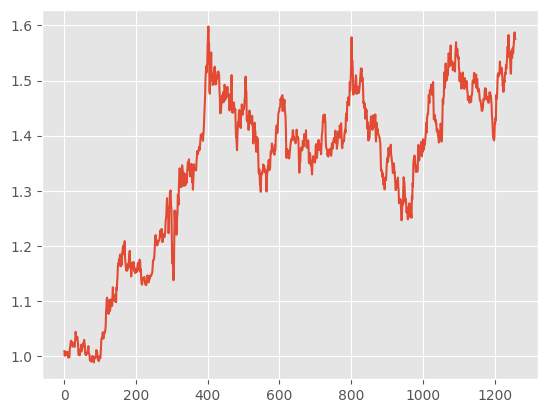

In [257]:
plt.plot(gold_return)

In [258]:
annualized_returns_average_asset

Ticker
AAPL    38.52%
BND      1.06%
EEM      2.86%
GLD      9.54%
JPM     14.83%
SPY     15.61%
TSM     26.57%
XOM     13.16%
dtype: str

## 3.7 Sensitivity Test

<BarContainer object of 8 artists>

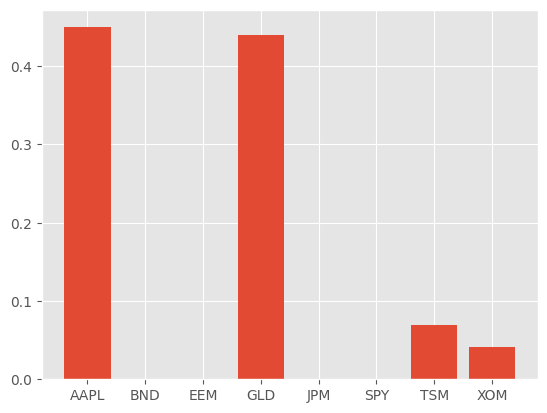

In [259]:
#LASTLY: CHECKING MPTs SENSITIVITY TO THE INPUT - TRYING DIFFERENT TIME-FRAMES AS INPUT

#comparing tangency portfolios:
plt.bar(data.columns, tangency_portfolio.x)


In [260]:
tickers

['TSM', 'AAPL', 'JPM', 'XOM', 'EEM', 'SPY', 'GLD', 'BND']

In [261]:
data_6y = yf.download(tickers, start='2018-01-01', end='2024-01-01', auto_adjust=True)['Close']
data_7y = yf.download(tickers, start='2017-01-01', end='2024-01-01', auto_adjust=True)['Close']
data_3y = yf.download(tickers, start='2021-01-01', end='2024-01-01', auto_adjust=True)['Close']

[*********************100%***********************]  8 of 8 completed
[*********************100%***********************]  8 of 8 completed
[*********************100%***********************]  8 of 8 completed


In [262]:
tangency_portfolio_6y = minimize(calculate_negative_sharpe_ratio, init_guess, args=(data_6y), constraints=constraints, bounds=bounds)
tangency_portfolio_7y = minimize(calculate_negative_sharpe_ratio, init_guess, args=(data_7y), constraints=constraints, bounds=bounds)
tangency_portfolio_3y = minimize(calculate_negative_sharpe_ratio, init_guess, args=(data_3y), constraints=constraints, bounds=bounds)

/var/folders/4v/1cr4vn8x4yv_p93m1plqw2s80000gn/T/ipykernel_23290/1426824286.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(data.columns, rotation=45, ha='right')
/var/folders/4v/1cr4vn8x4yv_p93m1plqw2s80000gn/T/ipykernel_23290/1426824286.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(data.columns, rotation=45, ha='right')
/var/folders/4v/1cr4vn8x4yv_p93m1plqw2s80000gn/T/ipykernel_23290/1426824286.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(data.columns, rotation=45, ha='right')


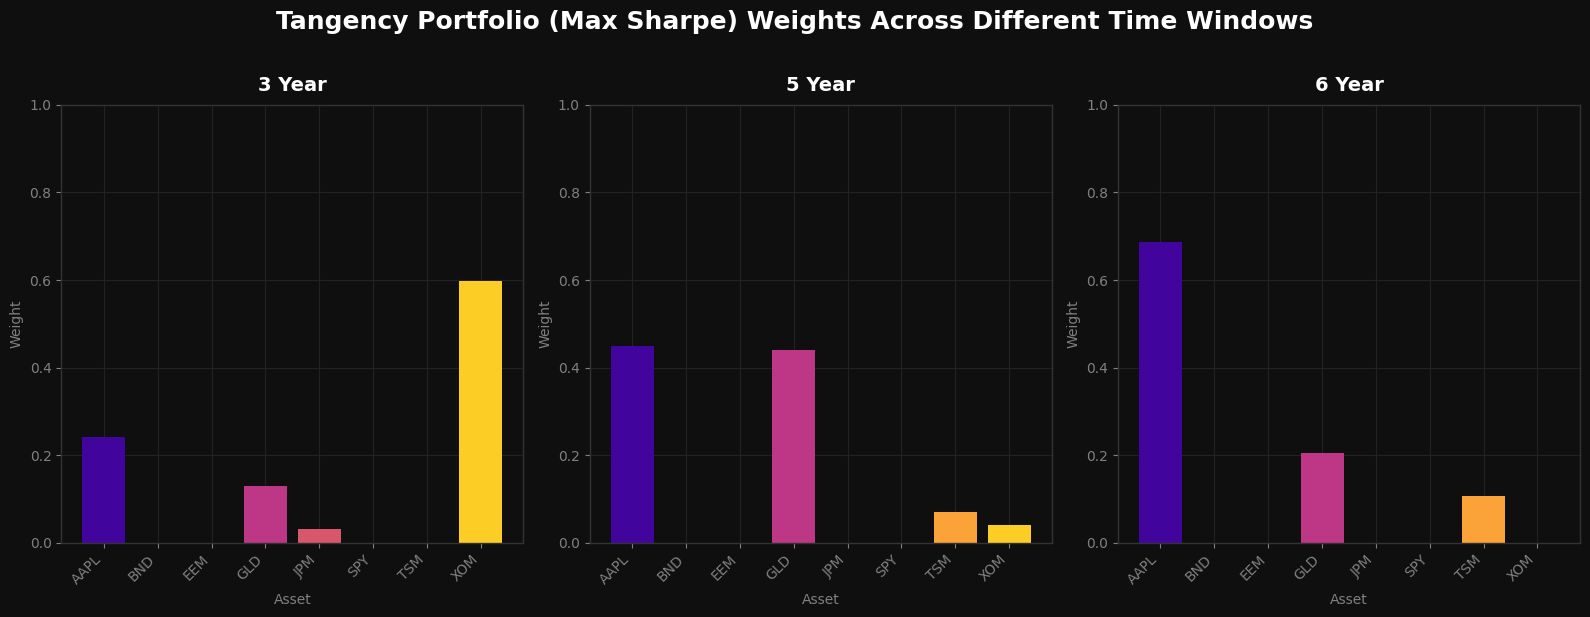

In [263]:
portfolios = {
    '3 Year': tangency_portfolio_3y,
    '5 Year': tangency_portfolio,
    '6 Year': tangency_portfolio_6y,
}

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.patch.set_facecolor('#0f0f0f')

for ax, (label, portfolio) in zip(axes, portfolios.items()):
    weights = portfolio.x
    ax.bar(data.columns, weights, color=plt.cm.plasma(np.linspace(0.1, 0.9, n)))
    
    # formatting
    ax.set_facecolor('#0f0f0f')
    ax.set_title(label, color='white', fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel('Asset', color='grey', fontsize=10)
    ax.set_ylabel('Weight', color='grey', fontsize=10)
    ax.tick_params(colors='grey')
    ax.set_xticklabels(data.columns, rotation=45, ha='right')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333333')
    ax.grid(True, color='#222222', linewidth=0.8)
    ax.set_ylim(0, 1)

fig.suptitle('Tangency Portfolio (Max Sharpe) Weights Across Different Time Windows', 
             color='white', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [264]:
# the graph above shows the huge sensitivity and over-reliance of MVO on the historical data you feed it. 

# Markowitz assumes expected returns are stationary — that the true mean return is a fixed number you're trying to estimate.
# But asset returns aren't stationary. Companies change, industries change, macro regimes change.
# No amount of historical data gives you a reliable estimate of future expected returns because the future distribution
# is genuinely different from the past one.

# Day 4 - CAPM

## 4.1. Calculating Betas

In [265]:
from scipy.stats import linregress

#we will use SPY as a benchmark
spy_returns = data['SPY'].pct_change().dropna()
betas = {}
r2s = {}

#calculating betas into a dictionary
for col in data.columns:
    if col == 'SPY':
        continue
    asset_returns = data[col].pct_change().dropna()
    slope, intercept, r, p, se = linregress(spy_returns, asset_returns)
    betas[col] = slope
    r2s[col] = r**2


#turning into series for easier access.
betas_series = pd.Series(betas)
r2s_series = pd.Series(r2s)
print(betas_series)

AAPL    1.235198
BND     0.059259
EEM     0.827129
GLD     0.076613
JPM     1.112260
TSM     1.070613
XOM     0.900522
dtype: float64


In [266]:
#computing CAPM esitmated returns
spy_returns_annual = spy_returns.mean() * trading_days
capm_estimated_returns = rfr + betas_series * (spy_returns_annual - rfr)
capm_estimated_returns


AAPL    0.201211
BND     0.031284
EEM     0.142244
GLD     0.033792
JPM     0.183446
TSM     0.177428
XOM     0.152849
dtype: float64

In [267]:
#historic mean/expected asset returns
asset_annual_mean_returns = data.pct_change().mean() * trading_days
asset_annual_mean_returns

Ticker
AAPL    0.378031
BND     0.012835
EEM     0.053375
GLD     0.102324
JPM     0.189012
SPY     0.167224
TSM     0.298916
XOM     0.182362
dtype: float64

In [268]:
#compare actual with predicted:
capm_comparison_df = pd.DataFrame({'Betas': betas_series,
                                   'CAPM Estimation': capm_estimated_returns,
                                   'Real Mean Returns' : asset_annual_mean_returns,
                                   'Variance Explained by CAPM' : r2s})

capm_comparison_df = capm_comparison_df.dropna(axis=0) # dropping SPY - which has NaN because it's the benchmark

#CONCLUSION: capm estimated returns edviate significantly from actual mean returns for the majority of assets.
#the 1 factor (market exposure) that capm uses to estimate returns doesn't explain nearly enough variance in the markets.

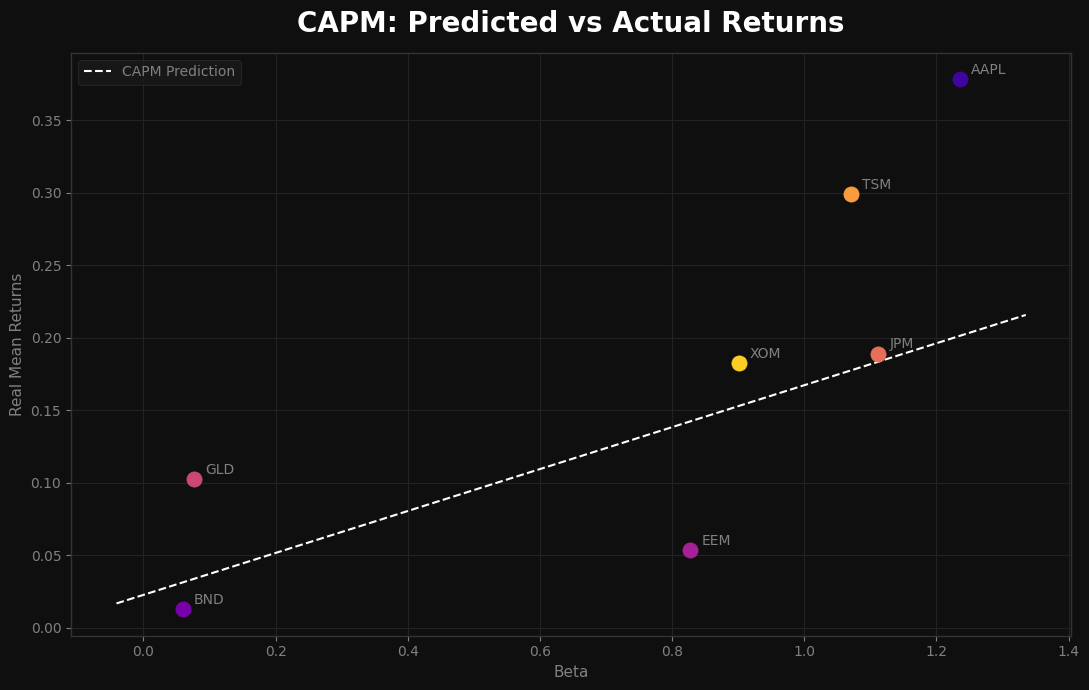

In [269]:
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#0f0f0f')

# CAPM line
x_line = np.linspace(capm_comparison_df['Betas'].min() - 0.1, capm_comparison_df['Betas'].max() + 0.1, 100)
y_line = rfr + x_line * (spy_returns_annual - rfr)
ax.plot(x_line, y_line, color='white', linewidth=1.5, linestyle='--', label='CAPM Prediction', zorder=2)

# one scatter point per asset
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(capm_comparison_df)))
for i, (asset, row) in enumerate(capm_comparison_df.iterrows()):
    ax.scatter(row['Betas'], row['Real Mean Returns'], color=colors[i], s=120, zorder=3)
    ax.annotate(asset, (row['Betas'], row['Real Mean Returns']),
                textcoords="offset points", xytext=(8, 4), color='grey', fontsize=10)

# formatting
ax.set_xlabel('Beta', color='grey', fontsize=11)
ax.set_ylabel('Real Mean Returns', color='grey', fontsize=11)
ax.set_title('CAPM: Predicted vs Actual Returns', color='white', fontsize=20, fontweight='bold', pad=15)
ax.tick_params(colors='grey')
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')
ax.grid(True, color='#222222', linewidth=0.8)
ax.legend(facecolor='#1a1a1a', edgecolor='#333333', labelcolor='grey', fontsize=10)

plt.tight_layout()
plt.show()

In [270]:
# if returns were 100% accurate, the asset returns would sit on the capm line
# this shows that the 1 factor doesnt explain nearly enough variance to be useful.

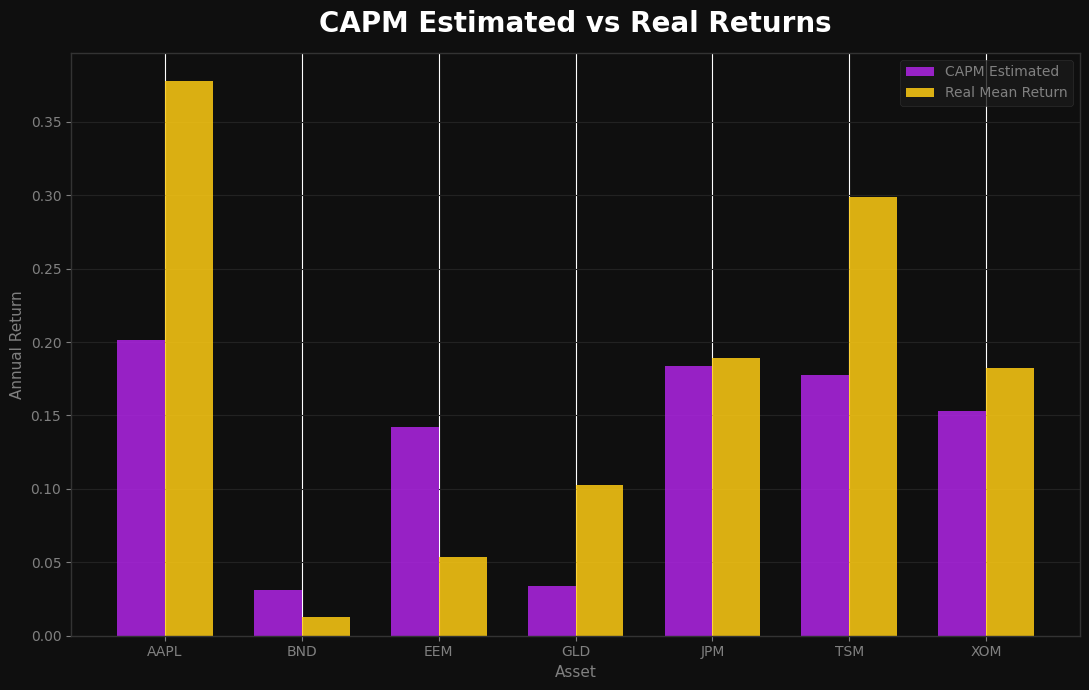

In [271]:
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#0f0f0f')

x = np.arange(len(capm_comparison_df))
width = 0.35

ax.bar(x - width/2, capm_comparison_df['CAPM Estimation'], width, 
       label='CAPM Estimated', color="#b025e6", alpha=0.85)
ax.bar(x + width/2, capm_comparison_df['Real Mean Returns'], width, 
       label='Real Mean Return', color="#ffcc13", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(capm_comparison_df.index, color='grey', fontsize=10)
ax.set_xlabel('Asset', color='grey', fontsize=11)
ax.set_ylabel('Annual Return', color='grey', fontsize=11)
ax.set_title('CAPM Estimated vs Real Returns', color='white', fontsize=20, fontweight='bold', pad=15)
ax.tick_params(colors='grey')
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')
ax.grid(True, color='#222222', linewidth=0.8, axis='y')
ax.legend(facecolor='#1a1a1a', edgecolor='#333333', labelcolor='grey', fontsize=10)

plt.tight_layout()
plt.show()

# Day 5 - Out of Sample Performance Test

In [272]:
#training on 3 years, then checking performance on latter 2.

In [273]:
train_start_date = '2019-01-03'
train_end_date = '2021-12-31'
test_start_date = '2022-01-01'
test_end_date = '2023-12-31'

train_data = data.loc[train_start_date : train_end_date]
test_data = data.loc[test_start_date : test_end_date]

In [274]:
train_data

Ticker,AAPL,BND,EEM,GLD,JPM,SPY,TSM,XOM
Date,,,,,,,,
2019-01-03,33.768074,64.572388,32.714989,122.430000,80.095512,219.626282,29.389696,49.234131
2019-01-04,35.209610,64.377953,33.770039,121.440002,83.048248,226.982895,29.911461,51.049377
2019-01-07,35.131241,64.280678,33.846622,121.860001,83.105980,228.772583,30.133846,51.314854
2019-01-08,35.800957,64.199654,33.974247,121.529999,82.949272,230.921936,29.885794,51.687943
2019-01-09,36.408913,64.288773,34.578335,122.309998,82.809059,232.001144,30.458893,51.960587
...,...,...,...,...,...,...,...,...
2021-12-27,176.459717,73.956078,44.365376,169.369995,141.756699,451.449554,114.628281,53.338230
2021-12-28,175.442032,73.947380,44.220333,168.639999,142.186874,451.080627,114.030388,53.165863
2021-12-29,175.530121,73.703362,44.020897,168.589996,142.115173,451.657623,113.423141,52.700481


In [275]:
init_guess

array([0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125])

In [276]:
#fitting tangency portfolio on train data
rfr = import_rfr(train_start_date, train_end_date)
print('RFR Train:',rfr)

constraints_train = ({
    'type':'eq',
    'fun':lambda weights: np.sum(weights) - 1
    })

n = len(train_data.columns)
bounds_train = [(0,1)] * n

tangency_portfolio_train = minimize(calculate_negative_sharpe_ratio, init_guess, args=(train_data,), constraints=constraints_train, bounds=bounds_train)

[*********************100%***********************]  1 of 1 completed


RFR Train: 0.014843827791561355


Text(0.5, 1.0, 'Tangency Portfolio Weights (Stress Test)')

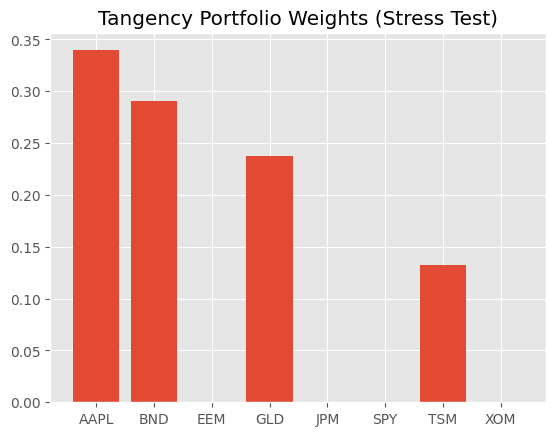

In [277]:
plt.bar(train_data.columns, tangency_portfolio_train.x)
plt.title('Tangency Portfolio Weights (Stress Test)')

In [278]:
#reporting train performance:
print('Train Data Performance:')
tangency_port_train_volatility = calculate_volatility(tangency_portfolio_train.x, train_data)
tangency_port_train_mean_return = calculate_mean_portfolio_returns(tangency_portfolio_train.x, train_data)
tangency_port_train_cagr = calculate_cagr(tangency_portfolio_train.x, train_data)
tangency_port_train_sharpe = calculate_sharpe_ratio(tangency_portfolio_train.x, train_data)

print('Train Tangency Portfolio Volatility:', tangency_port_train_volatility)
print('Train Tangency Portfolio Mean Returns:', tangency_port_train_mean_return)
print('Train Tangency Portfolio CAGR:', tangency_port_train_cagr)
print('Train Tangency Portfolio Sharpe Ratio:',tangency_port_train_sharpe)

#comparing to test performance:
print('Test Data Performance:')
tangency_port_test_volatility = calculate_volatility(tangency_portfolio_train.x, test_data)
tangency_port_test_mean_return = calculate_mean_portfolio_returns(tangency_portfolio_train.x, test_data)
tangency_port_test_cagr = calculate_cagr(tangency_portfolio_train.x, test_data)
tangency_port_test_sharpe = calculate_sharpe_ratio(tangency_portfolio_train.x, test_data)

print('Test Tangency Portfolio Volatility:', tangency_port_test_volatility)
print('Test Tangency Portfolio Mean Returns:', tangency_port_test_mean_return)
print('Test Tangency Portfolio CAGR:', tangency_port_test_cagr)
print('Test Tangency Portfolio Sharpe Ratio:',tangency_port_test_sharpe)

Train Data Performance:
Train Tangency Portfolio Volatility: 0.15817158280834498
Train Tangency Portfolio Mean Returns: 0.31555606026373295
Train Tangency Portfolio CAGR: 0.3531810679330707
Train Tangency Portfolio Sharpe Ratio: 1.9011773615273344
Test Data Performance:
Test Tangency Portfolio Volatility: 0.14757817220474834
Test Tangency Portfolio Mean Returns: 0.029532718625538017
Test Tangency Portfolio CAGR: 0.018821596851369193
Test Tangency Portfolio Sharpe Ratio: 0.09953294999207238


In [279]:
#plotting the return paths throughout the test and train period for the portfolio
stress_test_return_path = calculate_return_path(tangency_portfolio_train.x, data)

#converting into series for earlier plotting
stress_test_return_path = pd.Series(stress_test_return_path, index=data.index)
stress_test_return_path.dropna()

Date
2019-01-03    0.961615
2019-01-04    0.975134
2019-01-07    0.975731
2019-01-08    0.979998
2019-01-09    0.990030
                ...   
2023-12-22    2.500209
2023-12-26    2.507192
2023-12-27    2.515631
2023-12-28    2.512440
2023-12-29    2.502967
Length: 1257, dtype: float64

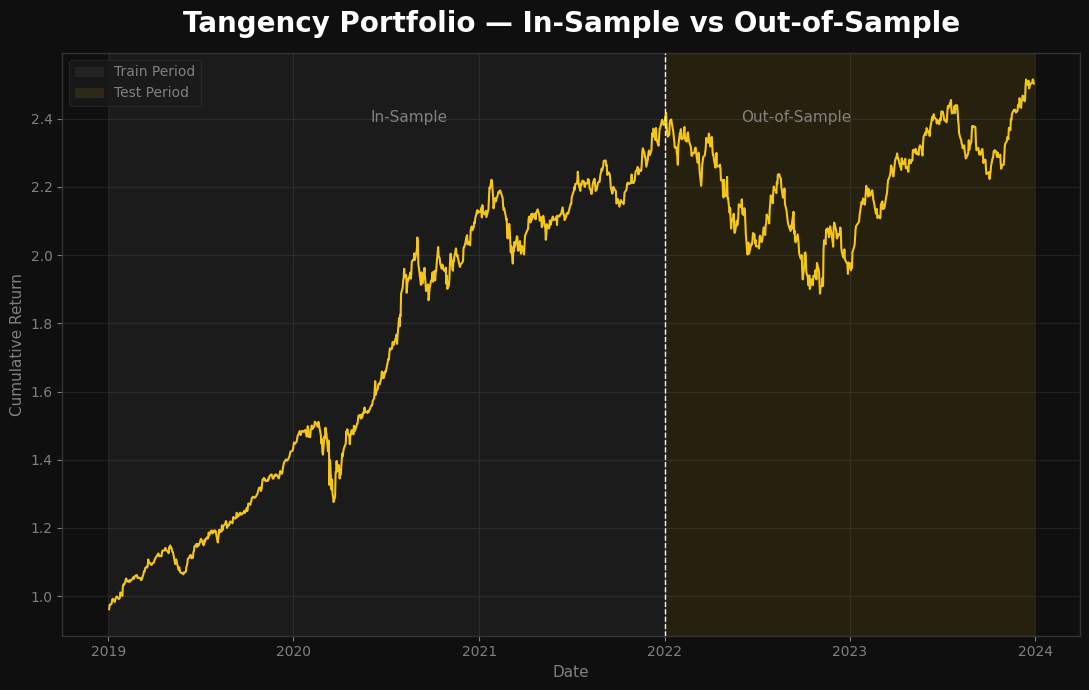

In [280]:
#return path across 5 years with the weights fitted on the first three.

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#0f0f0f')

# plot the return path
ax.plot(stress_test_return_path.index, stress_test_return_path.values,
        color='#f5c518', linewidth=1.5, zorder=2)

# vertical line separating train and test
split_date = '2022-01-01'
ax.axvline(x=pd.Timestamp(split_date), color='white', linewidth=1, linestyle='--', zorder=3)

# shade the two regions
ax.axvspan(stress_test_return_path.index[0], pd.Timestamp(split_date),
           alpha=0.05, color='white', label='Train Period')
ax.axvspan(pd.Timestamp(split_date), stress_test_return_path.index[-1],
           alpha=0.1, color='#f5c518', label='Test Period')

# label the two regions
ax.text(pd.Timestamp('2020-06-01'), stress_test_return_path.max() * 0.95,
        'In-Sample', color='grey', fontsize=11)
ax.text(pd.Timestamp('2022-06-01'), stress_test_return_path.max() * 0.95,
        'Out-of-Sample', color='grey', fontsize=11)

# formatting
ax.set_xlabel('Date', color='grey', fontsize=11)
ax.set_ylabel('Cumulative Return', color='grey', fontsize=11)
ax.set_title('Tangency Portfolio — In-Sample vs Out-of-Sample', color='white', fontsize=20, fontweight='bold', pad=15)
ax.tick_params(colors='grey')
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')
ax.grid(True, color='#222222', linewidth=0.8)
ax.legend(facecolor='#1a1a1a', edgecolor='#333333', labelcolor='grey', fontsize=10)

plt.tight_layout()
plt.show()

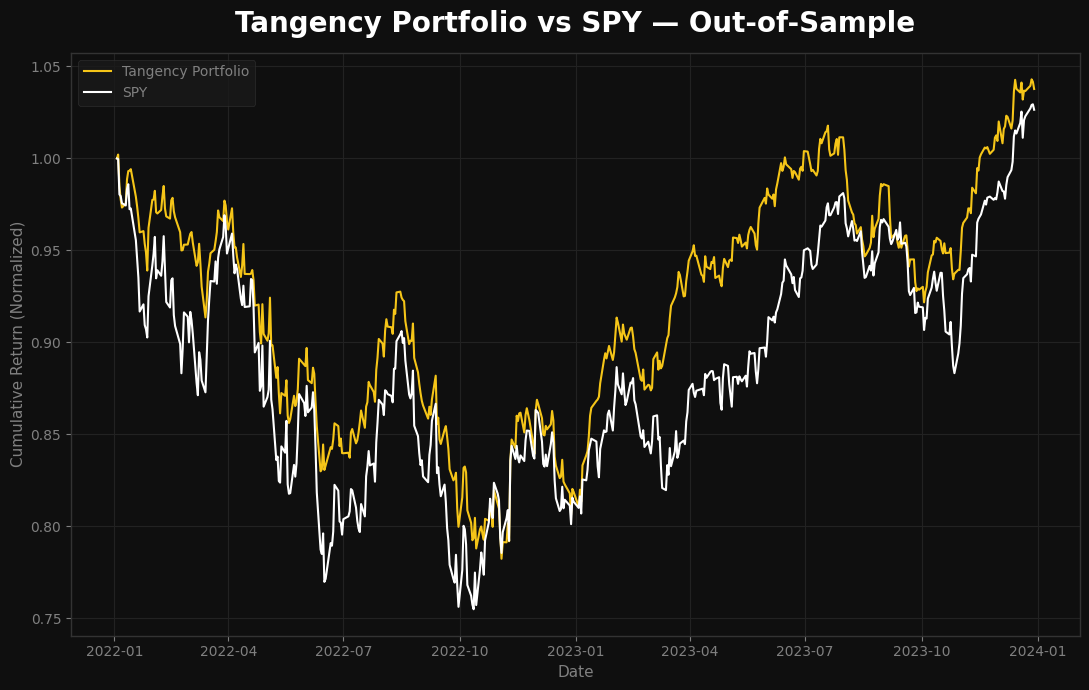

In [281]:
#comparing portfolio returns on test data with spy returns in the same period:

# isolate test period
test_start = '2022-01-01'
portfolio_test = stress_test_return_path[test_start:]

# spy return path over same period
spy_weights = np.array([1.0 if c == 'SPY' else 0.0 for c in data.columns])
spy_return_path = pd.Series(calculate_return_path(spy_weights, data), index=data.index)
spy_test = spy_return_path[test_start:]

# normalize both to start at 1 on the first day of test period
portfolio_test = portfolio_test / portfolio_test.iloc[0]
spy_test = spy_test / spy_test.iloc[0]

# plot
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#0f0f0f')

ax.plot(portfolio_test.index, portfolio_test.values, color='#f5c518', linewidth=1.5, label='Tangency Portfolio')
ax.plot(spy_test.index, spy_test.values, color='white', linewidth=1.5, label='SPY')

ax.set_xlabel('Date', color='grey', fontsize=11)
ax.set_ylabel('Cumulative Return (Normalized)', color='grey', fontsize=11)
ax.set_title('Tangency Portfolio vs SPY — Out-of-Sample', color='white', fontsize=20, fontweight='bold', pad=15)
ax.tick_params(colors='grey')
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')
ax.grid(True, color='#222222', linewidth=0.8)
ax.legend(facecolor='#1a1a1a', edgecolor='#333333', labelcolor='grey', fontsize=10)

plt.tight_layout()
plt.show()

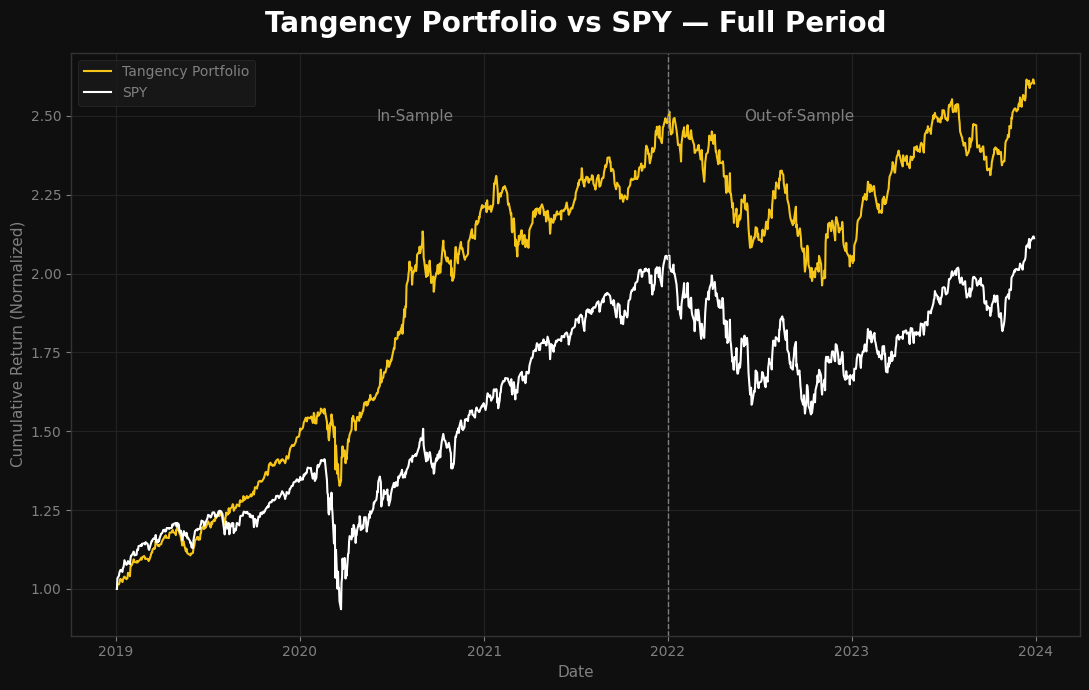

In [282]:
# normalize both to start at 1 on the first day
portfolio_full = stress_test_return_path.dropna() / stress_test_return_path.dropna().iloc[0]
spy_full = spy_return_path.dropna() / spy_return_path.dropna().iloc[0]

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#0f0f0f')

ax.plot(portfolio_full.index, portfolio_full.values, color='#f5c518', linewidth=1.5, label='Tangency Portfolio')
ax.plot(spy_full.index, spy_full.values, color='white', linewidth=1.5, label='SPY')

# train/test split line
ax.axvline(x=pd.Timestamp('2022-01-01'), color='grey', linewidth=1, linestyle='--')
ax.text(pd.Timestamp('2020-06-01'), portfolio_full.max() * 0.95, 'In-Sample', color='grey', fontsize=11)
ax.text(pd.Timestamp('2022-06-01'), portfolio_full.max() * 0.95, 'Out-of-Sample', color='grey', fontsize=11)

ax.set_xlabel('Date', color='grey', fontsize=11)
ax.set_ylabel('Cumulative Return (Normalized)', color='grey', fontsize=11)
ax.set_title('Tangency Portfolio vs SPY — Full Period', color='white', fontsize=20, fontweight='bold', pad=15)
ax.tick_params(colors='grey')
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')
ax.grid(True, color='#222222', linewidth=0.8)
ax.legend(facecolor='#1a1a1a', edgecolor='#333333', labelcolor='grey', fontsize=10)

plt.tight_layout()
plt.show()

In [283]:
# conclusion: the dominance of the optimal portfolio over the
# benchmark SPY basically vanished in the out-of-sample period, suggesting overfitting.

In [284]:
#the poorer performance in the test period could be due to a broader worse period in the market however.
# for an accurate assesment, we must compare to an equal weight portfolio baseline.


In [285]:
stress_test_return_path

Date
2019-01-02         NaN
2019-01-03    0.961615
2019-01-04    0.975134
2019-01-07    0.975731
2019-01-08    0.979998
                ...   
2023-12-22    2.500209
2023-12-26    2.507192
2023-12-27    2.515631
2023-12-28    2.512440
2023-12-29    2.502967
Length: 1258, dtype: float64

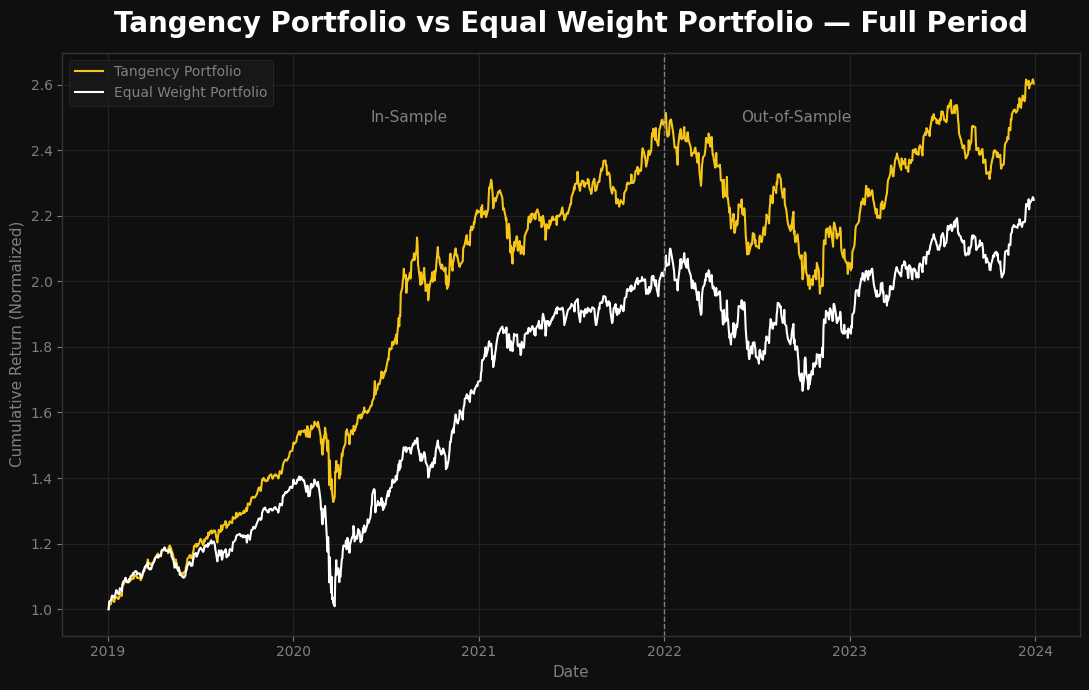

In [286]:
# normalize both to start at 1 on the first day
portfolio_full = stress_test_return_path.dropna() / stress_test_return_path.dropna().iloc[0]
eq_return_path = pd.Series(eq_return_path, stress_test_return_path.index)
eq_full = eq_return_path.dropna() / eq_return_path.dropna().iloc[0]

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#0f0f0f')

ax.plot(portfolio_full.index, portfolio_full.values, color='#f5c518', linewidth=1.5, label='Tangency Portfolio')
ax.plot(eq_full.index, eq_full.values, color='white', linewidth=1.5, label='Equal Weight Portfolio')

# train/test split line
ax.axvline(x=pd.Timestamp('2022-01-01'), color='grey', linewidth=1, linestyle='--')
ax.text(pd.Timestamp('2020-06-01'), portfolio_full.max() * 0.95, 'In-Sample', color='grey', fontsize=11)
ax.text(pd.Timestamp('2022-06-01'), portfolio_full.max() * 0.95, 'Out-of-Sample', color='grey', fontsize=11)

ax.set_xlabel('Date', color='grey', fontsize=11)
ax.set_ylabel('Cumulative Return (Normalized)', color='grey', fontsize=11)
ax.set_title('Tangency Portfolio vs Equal Weight Portfolio — Full Period', color='white', fontsize=20, fontweight='bold', pad=15)
ax.tick_params(colors='grey')
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')
ax.grid(True, color='#222222', linewidth=0.8)
ax.legend(facecolor='#1a1a1a', edgecolor='#333333', labelcolor='grey', fontsize=10)

plt.tight_layout()
plt.show()

In [287]:
#calculating out of sample return of both:
oos_start = '2022-01-01'

portfolio_oos = portfolio_full[portfolio_full.index >= oos_start]
eq_oos = eq_full[eq_full.index >= oos_start]

tangency_total_return = (portfolio_oos.iloc[-1] / portfolio_oos.iloc[0] - 1) * 100
eq_total_return = (eq_oos.iloc[-1] / eq_oos.iloc[0] - 1) * 100

print(f"Tangency Portfolio OOS Total Return: {tangency_total_return:.2f}%")
print(f"Equal Weight Portfolio OOS Total Return: {eq_total_return:.2f}%")

Tangency Portfolio OOS Total Return: 3.78%
Equal Weight Portfolio OOS Total Return: 9.54%
